In [1]:
# ============================================================
# Cell 1: Environment Setup & Core Package Imports
# ============================================================

# --- Core system ---
import os
import sys
import random
import warnings

# --- Numerical & data handling ---
import numpy as np
import pandas as pd

# --- Signal processing ---
from scipy import signal

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Machine Learning ---
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report

# --- Deep Learning ---
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# --- Reproducibility ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# --- Device Configuration ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Visualization Style ---
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 11

# --- Warnings ---
warnings.filterwarnings("ignore")

print(" Environment setup complete")
print(f" Using device: {device}")
print(f" PyTorch version: {torch.__version__}")


 Environment setup complete
 Using device: cuda
 PyTorch version: 2.10.0+cu128


In [3]:
# ============================================================
# Cell 2: Dataset Path Verification & Directory Inspection
# ============================================================

DATASET_PATH = "/kaggle/input/datasets/mjalal092/emowear-physiological-signals-resp-ecg-eda"

print(" Confirming dataset path:")
print(DATASET_PATH)

print("\n Files inside dataset folder:")
for file in os.listdir(DATASET_PATH):
    print(" -", file)

 Confirming dataset path:
/kaggle/input/datasets/mjalal092/emowear-physiological-signals-resp-ecg-eda

 Files inside dataset folder:
 - csv
 - questionnaire.csv
 - meta.csv


In [8]:
# ============================================================
# Cell 3 : Locate Actual CSV Data Root
# ============================================================

DATASET_ROOT = "/kaggle/input/datasets/mjalal092/emowear-physiological-signals-resp-ecg-eda/csv/csv"

print("Resolved dataset root:")
print(DATASET_ROOT)

print("\nTop-level entries in resolved dataset root:")
items = os.listdir(DATASET_ROOT)

print("Number of entries:", len(items))
print("Sample entries:")
for item in items[:5]:
    print(" -", item)

Resolved dataset root:
/kaggle/input/datasets/mjalal092/emowear-physiological-signals-resp-ecg-eda/csv/csv

Top-level entries in resolved dataset root:
Number of entries: 48
Sample entries:
 - 01-9TZK
 - 40-9W74
 - 24-9VL3
 - 27-9VUW
 - 17-9UTL


In [10]:
# ============================================================
# Cell 4: Subject Folder Inspection & Signal File Mapping
# ============================================================

# Pick one subject/session folder for inspection
subject_ids = sorted(os.listdir(DATASET_ROOT))
sample_subject = subject_ids[0]

SUBJECT_PATH = os.path.join(DATASET_ROOT, sample_subject)

print("Inspecting subject/session:")
print(sample_subject)

print("\nFiles inside subject folder:")
files = sorted(os.listdir(SUBJECT_PATH))
for f in files:
    print(" -", f)

Inspecting subject/session:
01-9TZK

Files inside subject folder:
 - markers-phase2.csv
 - markers-unique.csv
 - params.csv
 - signals-bh3-acc.csv
 - signals-bh3-bb.csv
 - signals-bh3-br.csv
 - signals-bh3-ecg.csv
 - signals-bh3-hr.csv
 - signals-bh3-hr_confidence.csv
 - signals-bh3-rr.csv
 - signals-bh3-rsp.csv
 - signals-e4-acc.csv
 - signals-e4-bvp.csv
 - signals-e4-eda.csv
 - signals-e4-hr.csv
 - signals-e4-ibi.csv
 - signals-e4-skt.csv
 - surveys.csv


Selected subject: 01-9TZK

Signal files used:
RESP: /kaggle/input/datasets/mjalal092/emowear-physiological-signals-resp-ecg-eda/csv/csv/01-9TZK/signals-bh3-rsp.csv
ECG : /kaggle/input/datasets/mjalal092/emowear-physiological-signals-resp-ecg-eda/csv/csv/01-9TZK/signals-bh3-ecg.csv
EDA : /kaggle/input/datasets/mjalal092/emowear-physiological-signals-resp-ecg-eda/csv/csv/01-9TZK/signals-e4-eda.csv

RESP shape: (130025, 2)
ECG shape : (1300250, 2)
EDA shape : (20412, 2)

RESP columns: ['timestamp', 'value']
ECG columns : ['timestamp', 'value']
EDA columns : ['timestamp', 'value']


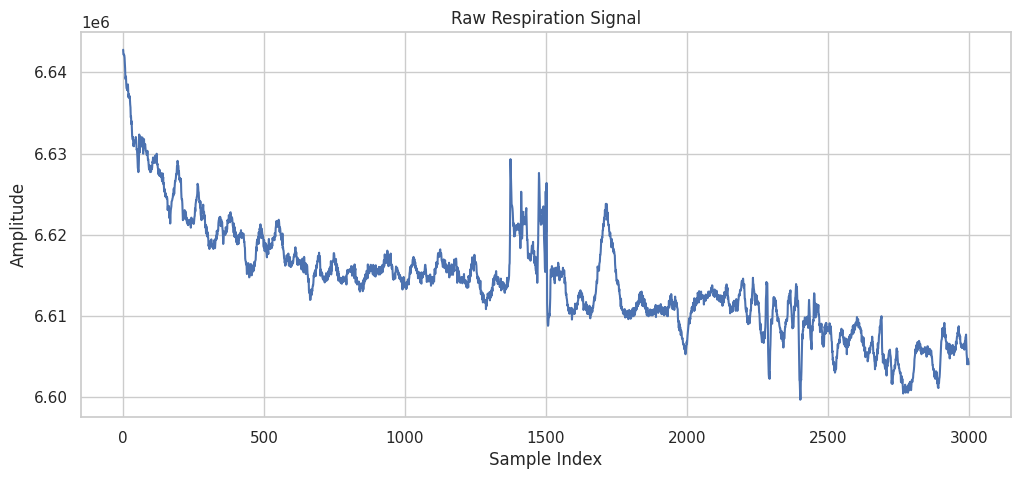

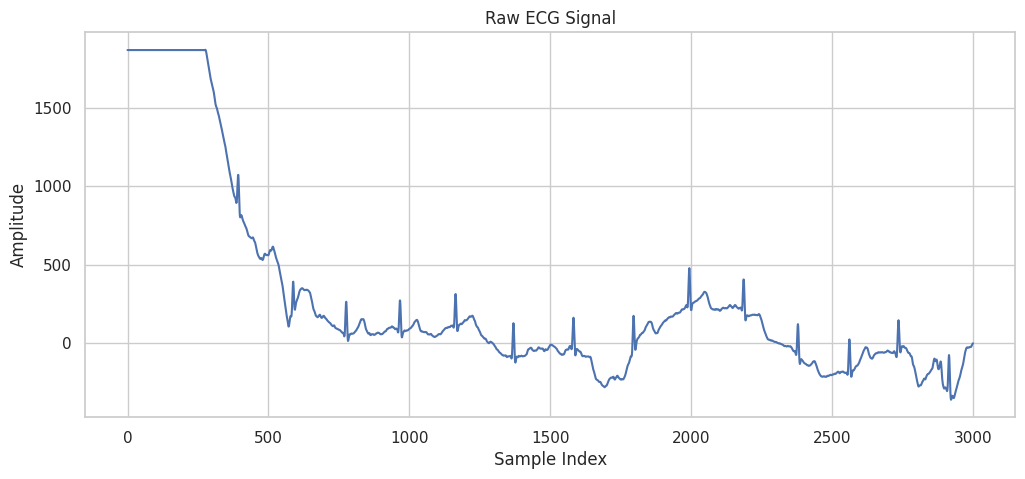

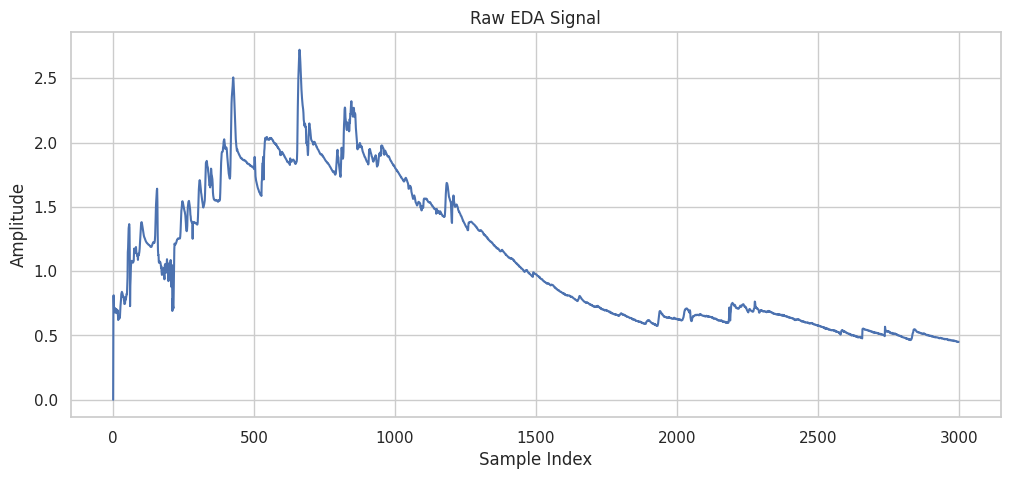

In [11]:
# ============================================================
# Cell 5: Load and Visualize Raw Physiological Signals
# ============================================================

# Select one subject for visualization
subject_id = sorted(os.listdir(DATASET_ROOT))[0]
subject_path = os.path.join(DATASET_ROOT, subject_id)

print("Selected subject:", subject_id)

# Define signal file paths
resp_path = os.path.join(subject_path, "signals-bh3-rsp.csv")
ecg_path  = os.path.join(subject_path, "signals-bh3-ecg.csv")
eda_path  = os.path.join(subject_path, "signals-e4-eda.csv")

print("\nSignal files used:")
print("RESP:", resp_path)
print("ECG :", ecg_path)
print("EDA :", eda_path)

# Load CSV files
resp_df = pd.read_csv(resp_path)
ecg_df  = pd.read_csv(ecg_path)
eda_df  = pd.read_csv(eda_path)

# Print basic info
print("\nRESP shape:", resp_df.shape)
print("ECG shape :", ecg_df.shape)
print("EDA shape :", eda_df.shape)

print("\nRESP columns:", list(resp_df.columns))
print("ECG columns :", list(ecg_df.columns))
print("EDA columns :", list(eda_df.columns))

# Plot first N samples for visualization
N = 3000

plt.figure()
plt.plot(resp_df.iloc[:N, 1])
plt.title("Raw Respiration Signal")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.show()

plt.figure()
plt.plot(ecg_df.iloc[:N, 1])
plt.title("Raw ECG Signal")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.show()

plt.figure()
plt.plot(eda_df.iloc[:N, 1])
plt.title("Raw EDA Signal")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.show()

In [12]:
# ============================================================
# Cell 6: Time Axis & Sampling Rate Inspection
# ============================================================

def inspect_time_axis(df, signal_name):
    timestamps = df["timestamp"].values
    diffs = np.diff(timestamps)

    print(f"\n{signal_name} time-axis inspection")
    print("First 5 timestamps:", timestamps[:5])
    print("Last  5 timestamps:", timestamps[-5:])
    print("Mean timestamp diff:", np.mean(diffs))
    print("Std  timestamp diff:", np.std(diffs))

    # Approximate sampling rate (Hz)
    if np.mean(diffs) > 0:
        fs = 1.0 / np.mean(diffs)
        print("Approx. sampling rate (Hz):", round(fs, 2))
    else:
        print("Sampling rate could not be estimated.")


inspect_time_axis(resp_df, "RESP")
inspect_time_axis(ecg_df,  "ECG")
inspect_time_axis(eda_df,  "EDA")


RESP time-axis inspection
First 5 timestamps: [-252.75737 -252.71737 -252.67737 -252.63737 -252.59737]
Last  5 timestamps: [4948.04263 4948.08263 4948.12263 4948.16263 4948.20263]
Mean timestamp diff: 0.04
Std  timestamp diff: 1.135231313492174e-13
Approx. sampling rate (Hz): 25.0

ECG time-axis inspection
First 5 timestamps: [-252.75737 -252.75337 -252.74937 -252.74537 -252.74137]
Last  5 timestamps: [4948.22263 4948.22663 4948.23063 4948.23463 4948.23863]
Mean timestamp diff: 0.004000000000000002
Std  timestamp diff: 2.789825193395977e-07
Approx. sampling rate (Hz): 250.0

EDA time-axis inspection
First 5 timestamps: [-166.0774  -165.82773 -165.57806 -165.32839 -165.07872]
Last  5 timestamps: [4928.95871 4929.20838 4929.45805 4929.70772 4929.95739]
Mean timestamp diff: 0.2496710004409387
Std  timestamp diff: 3.0005878284054967e-06
Approx. sampling rate (Hz): 4.01


In [13]:
# ============================================================
# Cell 7: Signal Filtering and Resampling Functions
# ============================================================

def bandpass_filter(signal_values, fs, lowcut, highcut, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = signal.butter(order, [low, high], btype="band")
    return signal.filtfilt(b, a, signal_values)


def lowpass_filter(signal_values, fs, cutoff, order=4):
    nyq = 0.5 * fs
    normal_cutoff = cutoff / nyq
    b, a = signal.butter(order, normal_cutoff, btype="low")
    return signal.filtfilt(b, a, signal_values)


def resample_signal(values, orig_fs, target_fs):
    duration = len(values) / orig_fs
    target_length = int(duration * target_fs)
    return signal.resample(values, target_length)


def preprocess_respiration(values, fs):
    filtered = bandpass_filter(values, fs, lowcut=0.1, highcut=0.5)
    return filtered


def preprocess_ecg(values, fs):
    filtered = bandpass_filter(values, fs, lowcut=0.5, highcut=40.0)
    return filtered


def preprocess_eda(values, fs):
    filtered = lowpass_filter(values, fs, cutoff=1.0)
    return filtered


print("Preprocessing functions for RESP, ECG, and EDA are defined.")


Preprocessing functions for RESP, ECG, and EDA are defined.


Processed signal lengths (after resampling):
RESP: 130025
ECG : 130025
EDA : 127575


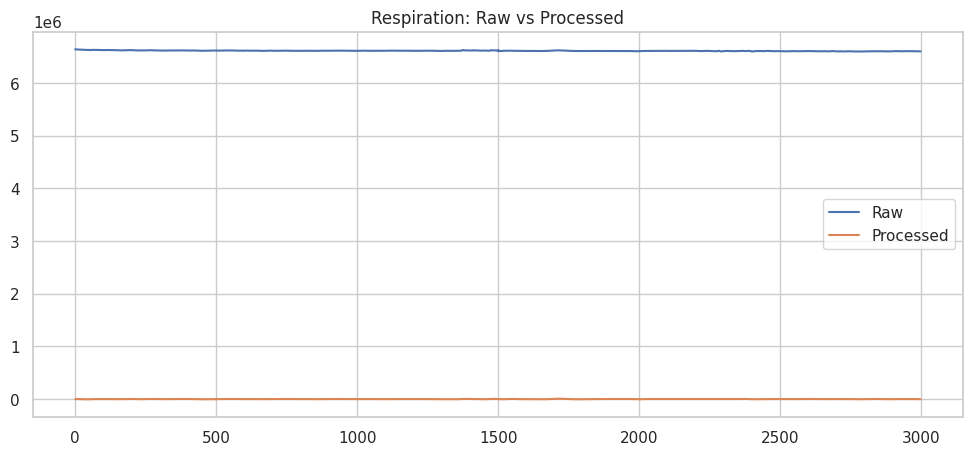

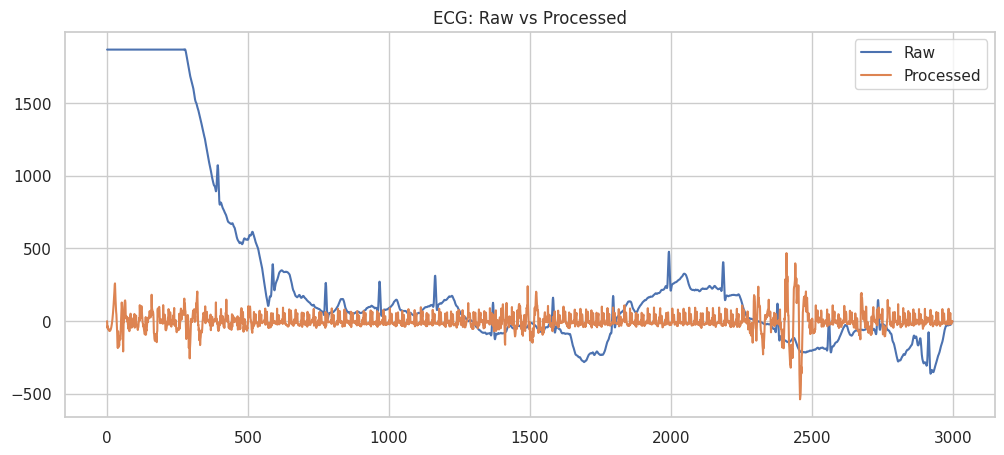

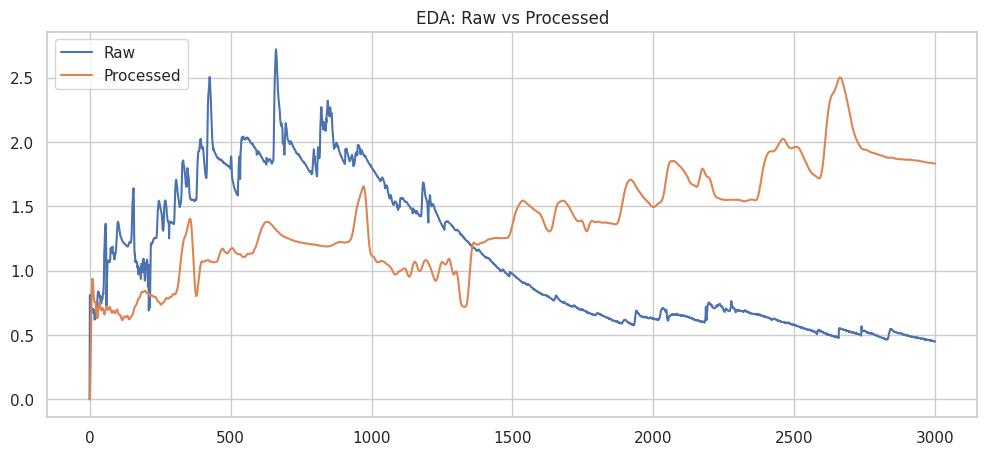

In [15]:
# ============================================================
# Cell 8: Apply Preprocessing to One Subject and Visualize
# ============================================================

# Known sampling rates (confirmed in Cell 6)
FS_RESP = 25
FS_ECG  = 250
FS_EDA  = 4
TARGET_FS = 25

# Select subject (same as earlier for consistency)
subject_id = sorted(os.listdir(DATASET_ROOT))[0]
subject_path = os.path.join(DATASET_ROOT, subject_id)

# Load raw signals
resp_df = pd.read_csv(os.path.join(subject_path, "signals-bh3-rsp.csv"))
ecg_df  = pd.read_csv(os.path.join(subject_path, "signals-bh3-ecg.csv"))
eda_df  = pd.read_csv(os.path.join(subject_path, "signals-e4-eda.csv"))

resp_raw = resp_df["value"].values
ecg_raw  = ecg_df["value"].values
eda_raw  = eda_df["value"].values

# Apply filtering
resp_filt = preprocess_respiration(resp_raw, FS_RESP)
ecg_filt  = preprocess_ecg(ecg_raw, FS_ECG)
eda_filt  = preprocess_eda(eda_raw, FS_EDA)

# Resample to target sampling rate
resp_proc = resample_signal(resp_filt, FS_RESP, TARGET_FS)
ecg_proc  = resample_signal(ecg_filt,  FS_ECG,  TARGET_FS)
eda_proc  = resample_signal(eda_filt,  FS_EDA,  TARGET_FS)

print("Processed signal lengths (after resampling):")
print("RESP:", len(resp_proc))
print("ECG :", len(ecg_proc))
print("EDA :", len(eda_proc))

# Plot comparison (raw vs processed)
N = 3000

plt.figure()
plt.plot(resp_raw[:N], label="Raw")
plt.plot(resp_proc[:N], label="Processed")
plt.title("Respiration: Raw vs Processed")
plt.legend()
plt.show()

plt.figure()
plt.plot(ecg_raw[:N], label="Raw")
plt.plot(ecg_proc[:N], label="Processed")
plt.title("ECG: Raw vs Processed")
plt.legend()
plt.show()

plt.figure()
plt.plot(eda_raw[:N], label="Raw")
plt.plot(eda_proc[:N], label="Processed")
plt.title("EDA: Raw vs Processed")
plt.legend()
plt.show()

Aligned signal length: 127575


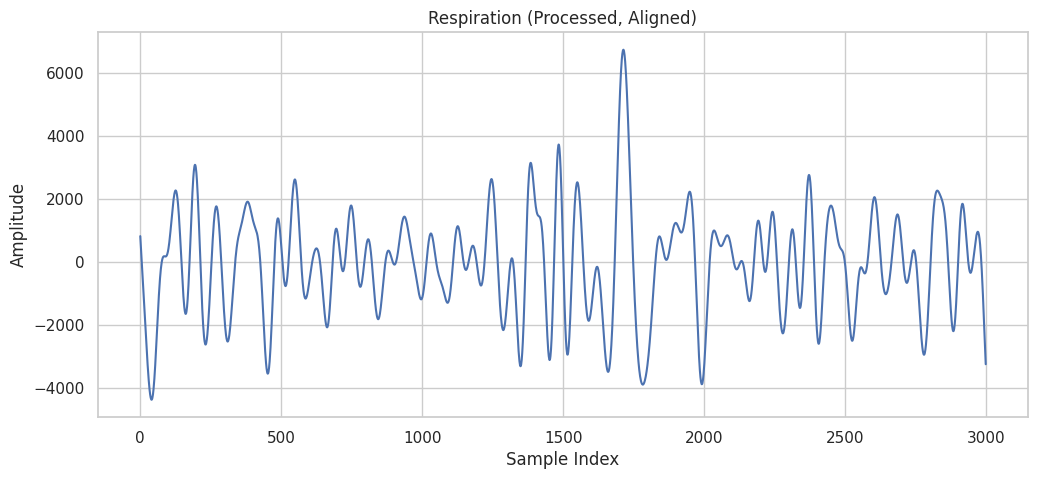

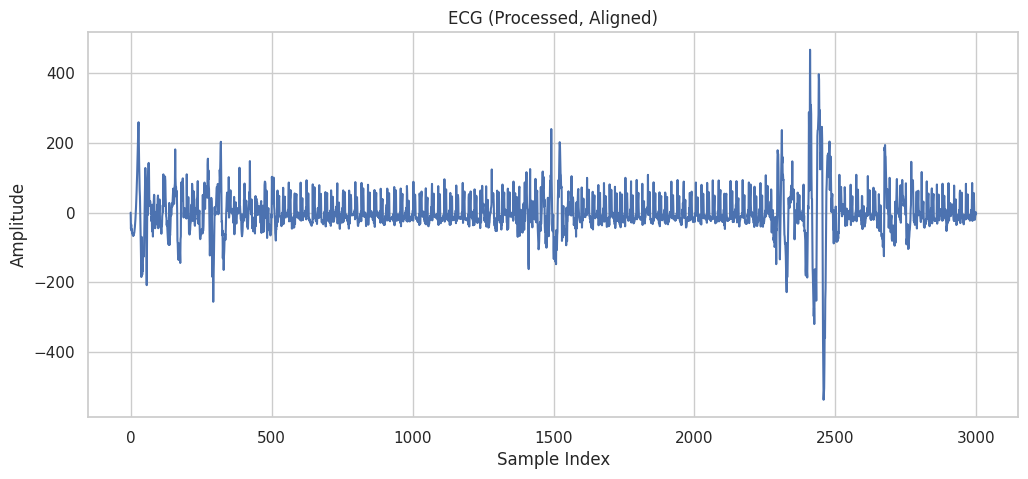

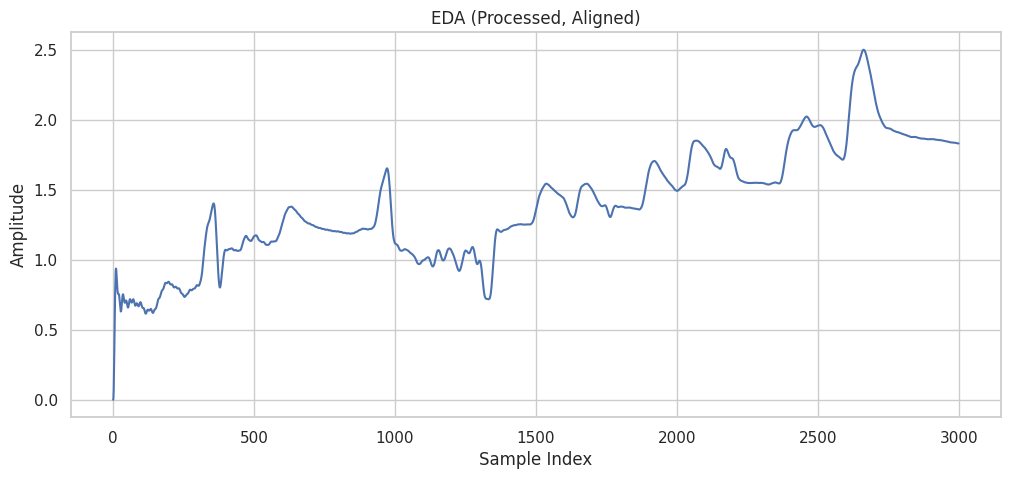

In [17]:
# ============================================================
# Cell 8.1: Align Signal Lengths & Correct Visualization
# ============================================================

# Align lengths
min_len = min(len(resp_proc), len(ecg_proc), len(eda_proc))

resp_proc_aligned = resp_proc[:min_len]
ecg_proc_aligned  = ecg_proc[:min_len]
eda_proc_aligned  = eda_proc[:min_len]

print("Aligned signal length:", min_len)

# Visualization scale correction (plot processed only)
N = 3000

plt.figure()
plt.plot(resp_proc_aligned[:N])
plt.title("Respiration (Processed, Aligned)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.show()

plt.figure()
plt.plot(ecg_proc_aligned[:N])
plt.title("ECG (Processed, Aligned)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.show()

plt.figure()
plt.plot(eda_proc_aligned[:N])
plt.title("EDA (Processed, Aligned)")
plt.xlabel("Sample Index")
plt.ylabel("Amplitude")
plt.show()

Number of windows created:
RESP: (510, 250)
ECG : (510, 250)
EDA : (510, 250)


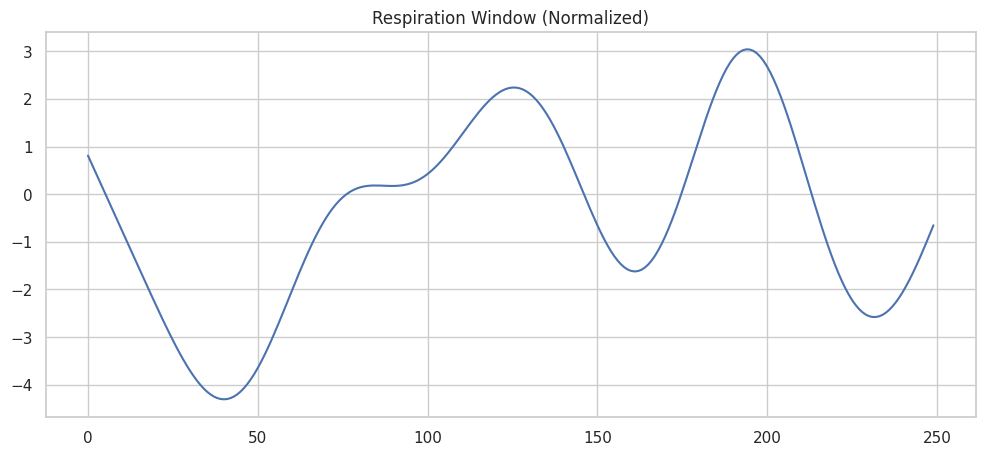

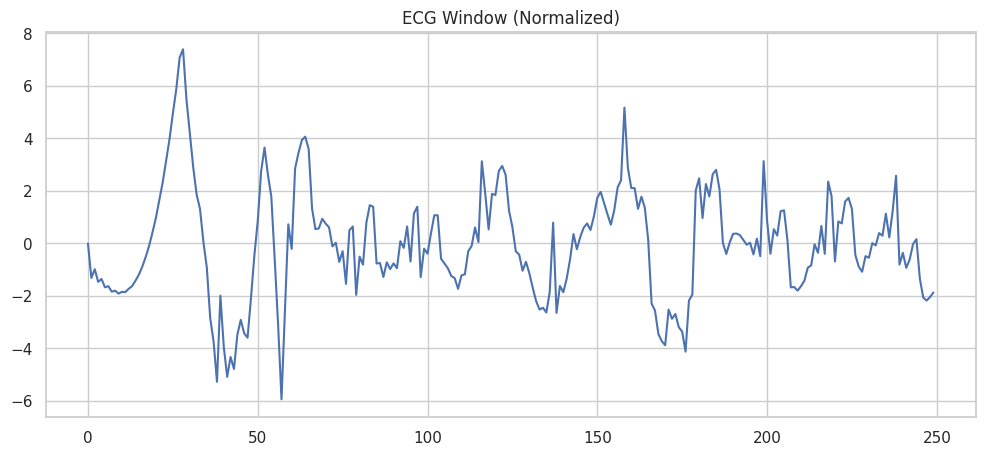

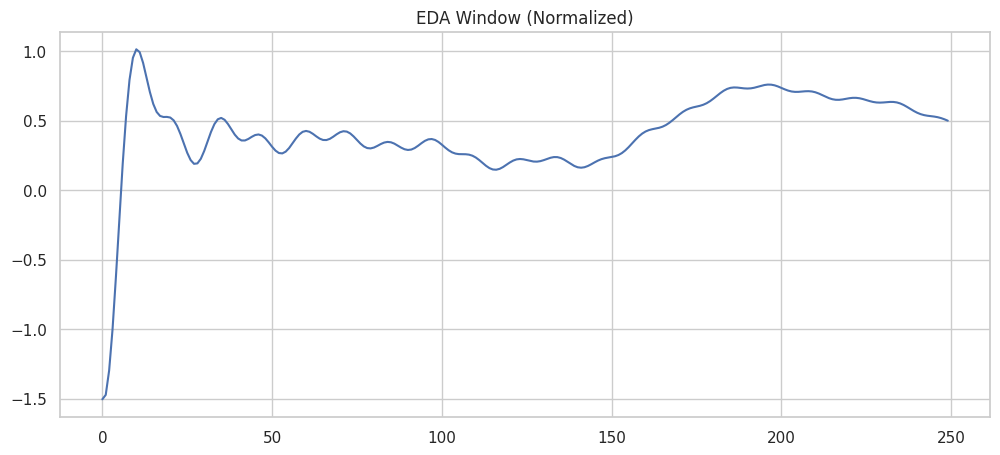

In [19]:
# ============================================================
# Cell 9: Subject-wise Normalization and Window Segmentation
# ============================================================

WINDOW_SEC = 10
FS = 25
WINDOW_SIZE = WINDOW_SEC * FS

def zscore_normalize(x):
    return (x - np.mean(x)) / (np.std(x) + 1e-8)

def segment_windows(signal_array, window_size):
    num_windows = len(signal_array) // window_size
    return np.array([
        signal_array[i * window_size : (i + 1) * window_size]
        for i in range(num_windows)
    ])

# Apply normalization
resp_norm = zscore_normalize(resp_proc_aligned)
ecg_norm  = zscore_normalize(ecg_proc_aligned)
eda_norm  = zscore_normalize(eda_proc_aligned)

# Segment into windows
resp_windows = segment_windows(resp_norm, WINDOW_SIZE)
ecg_windows  = segment_windows(ecg_norm,  WINDOW_SIZE)
eda_windows  = segment_windows(eda_norm,  WINDOW_SIZE)

print("Number of windows created:")
print("RESP:", resp_windows.shape)
print("ECG :", ecg_windows.shape)
print("EDA :", eda_windows.shape)

# Sanity check: visualize one window
idx = 0

plt.figure()
plt.plot(resp_windows[idx])
plt.title("Respiration Window (Normalized)")
plt.show()

plt.figure()
plt.plot(ecg_windows[idx])
plt.title("ECG Window (Normalized)")
plt.show()

plt.figure()
plt.plot(eda_windows[idx])
plt.title("EDA Window (Normalized)")
plt.show()

In [20]:
# ============================================================
# Cell 10: Label Extraction and Time Alignment (Single Subject)
# ============================================================

# Load survey labels
surveys_path = os.path.join(subject_path, "surveys.csv")
surveys_df = pd.read_csv(surveys_path)

print("Loaded surveys.csv")
print("Shape:", surveys_df.shape)

print("\nSurvey columns:")
for col in surveys_df.columns:
    print(" -", col)

print("\nFirst 5 survey entries:")
print(surveys_df.head())

Loaded surveys.csv
Shape: (38, 7)

Survey columns:
 - seq
 - exp
 - valence
 - arousal
 - dominance
 - liking
 - familiarity

First 5 survey entries:
   seq  exp  valence  arousal  dominance  liking  familiarity
0    1    7      6.4      7.7        6.6     6.5            3
1    2    4      5.0      3.0        4.0     3.1            4
2    3   40      3.0      3.1        5.6     1.0            1
3    4   17      3.0      2.9        2.7     1.0            1
4    5   23      1.0      5.0        4.0     1.0            1


In [21]:
# ============================================================
# Cell 10A: Stimulus Boundary Inspection (markers-phase2.csv)
# ============================================================

markers_path = os.path.join(subject_path, "markers-phase2.csv")
markers_df = pd.read_csv(markers_path)

print("Loaded markers-phase2.csv")
print("Shape:", markers_df.shape)

print("\nMarker columns:")
for col in markers_df.columns:
    print(" -", col)

print("\nFirst 10 marker entries:")
print(markers_df.head(10).to_string(index=False))

Loaded markers-phase2.csv
Shape: (38, 11)

Marker columns:
 - seq
 - exp
 - newExp
 - preB
 - vidB
 - postB
 - surveyB
 - walkB
 - walkE
 - walkDetect
 - walkFinish

First 10 marker entries:
 seq  exp   newExp     preB     vidB    postB  surveyB    walkB    walkE  walkDetect  walkFinish
   1    7  271.362  273.373  278.382  339.371  342.373  377.059  396.134  378.828959  403.581414
   2    4  403.335  405.336  410.348  472.726  475.729  515.514  534.579  516.874935  542.621503
   3   40  543.247  545.248  550.259  614.532  617.533  642.337  661.380  643.966899  671.416610
   4   17  672.058  674.058  679.070  738.137  741.138  764.889  783.952  766.520301  791.006452
   5   23  791.289  793.295  798.305  860.522  863.524  886.620  905.655  888.256233  914.300161
   6    2  914.526  916.527  921.536  982.905  985.906 1017.538 1036.586 1018.957297 1043.831856
   7   32 1044.111 1046.113 1051.125 1112.152 1115.154 1150.621 1169.685 1152.179316 1177.088994
   8   14 1178.228 1180.230 1185.

In [22]:
# ============================================================
# Cell 10B: Extract Stimulus Segments from markers-phase2.csv
# ============================================================

# Select relevant columns for stimulus segmentation
stimulus_segments = markers_df[["exp", "vidB", "postB"]].copy()

# Rename for clarity
stimulus_segments.columns = ["exp", "start_time", "end_time"]

print("Stimulus segment table created")
print("Number of stimuli:", len(stimulus_segments))

print("\nFirst 10 stimulus segments:")
print(stimulus_segments.head(10).to_string(index=False))

Stimulus segment table created
Number of stimuli: 38

First 10 stimulus segments:
 exp  start_time  end_time
   7     278.382   339.371
   4     410.348   472.726
  40     550.259   614.532
  17     679.070   738.137
  23     798.305   860.522
   2     921.536   982.905
  32    1051.125  1112.152
  14    1185.232  1246.666
  18    1337.684  1399.136
  25    1459.723  1522.307


In [23]:
# ============================================================
# Cell 10C: Window-to-Stimulus and Label Mapping (Single Subject)
# ============================================================

# Build window time ranges (in seconds)
window_start_times = np.arange(0, len(resp_proc_aligned) / FS, WINDOW_SEC)
window_end_times = window_start_times + WINDOW_SEC

print("Total windows:", len(window_start_times))

# Prepare container
window_exp_ids = []

# Assign each window to a stimulus
for ws, we in zip(window_start_times, window_end_times):
    match = stimulus_segments[
        (stimulus_segments["start_time"] <= ws) &
        (stimulus_segments["end_time"] >= we)
    ]
    if len(match) == 1:
        window_exp_ids.append(match.iloc[0]["exp"])
    else:
        window_exp_ids.append(np.nan)

window_exp_ids = np.array(window_exp_ids)

print("Assigned stimulus IDs (first 20):")
print(window_exp_ids[:20])

print("\nNumber of windows assigned to a stimulus:",
      np.sum(~np.isnan(window_exp_ids)))

# ---- Map stimulus exp -> survey labels ----
survey_lookup = surveys_df.set_index("exp")

# Use arousal for now (can switch later)
window_labels = []
for exp_id in window_exp_ids:
    if np.isnan(exp_id):
        window_labels.append(np.nan)
    else:
        window_labels.append(survey_lookup.loc[int(exp_id)]["arousal"])

window_labels = np.array(window_labels)

print("\nWindow labels (first 20):")
print(window_labels[:20])

print("\nNumber of labeled windows:",
      np.sum(~np.isnan(window_labels)))

Total windows: 511
Assigned stimulus IDs (first 20):
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan]

Number of windows assigned to a stimulus: 198

Window labels (first 20):
[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan]

Number of labeled windows: 198


In [25]:
# ============================================================
# Cell 11 : Label Discretization and Final Dataset
# ============================================================

NUM_WINDOWS = resp_windows.shape[0]

# Correct window start/end times based on actual windows
window_start_times = np.arange(NUM_WINDOWS) * WINDOW_SEC
window_end_times   = window_start_times + WINDOW_SEC

# ---- Map windows to stimulus exp IDs ----
window_exp_ids = []

for ws, we in zip(window_start_times, window_end_times):
    match = stimulus_segments[
        (stimulus_segments["start_time"] <= ws) &
        (stimulus_segments["end_time"] >= we)
    ]
    if len(match) == 1:
        window_exp_ids.append(match.iloc[0]["exp"])
    else:
        window_exp_ids.append(np.nan)

window_exp_ids = np.array(window_exp_ids)

# ---- Map exp → arousal labels ----
survey_lookup = surveys_df.set_index("exp")

window_labels = []
for exp_id in window_exp_ids:
    if np.isnan(exp_id):
        window_labels.append(np.nan)
    else:
        window_labels.append(survey_lookup.loc[int(exp_id)]["arousal"])

window_labels = np.array(window_labels)

# ---- Discretize arousal: binary classification ----
# 0 = low (<=4), 1 = high (>=6), drop middle
valid_mask = ~np.isnan(window_labels) & ((window_labels <= 4) | (window_labels >= 6))

y_final = np.where(window_labels <= 4, 0, 1)[valid_mask]

resp_final = resp_windows[valid_mask]
ecg_final  = ecg_windows[valid_mask]
eda_final  = eda_windows[valid_mask]

print("Final dataset shapes:")
print("RESP:", resp_final.shape)
print("ECG :", ecg_final.shape)
print("EDA :", eda_final.shape)
print("Labels:", y_final.shape)

print("\nClass distribution:")
print("Low arousal (0):", np.sum(y_final == 0))
print("High arousal (1):", np.sum(y_final == 1))

Final dataset shapes:
RESP: (160, 250)
ECG : (160, 250)
EDA : (160, 250)
Labels: (160,)

Class distribution:
Low arousal (0): 78
High arousal (1): 82


In [26]:
# ============================================================
# Cell 12: Build Full Dataset Across All Subjects
# ============================================================

X_resp_all, X_ecg_all, X_eda_all = [], [], []
y_all, groups_all = [], []

subject_ids = sorted(os.listdir(DATASET_ROOT))

for subj_id in subject_ids:
    subj_path = os.path.join(DATASET_ROOT, subj_id)

    # --- Load signals ---
    resp_df = pd.read_csv(os.path.join(subj_path, "signals-bh3-rsp.csv"))
    ecg_df  = pd.read_csv(os.path.join(subj_path, "signals-bh3-ecg.csv"))
    eda_df  = pd.read_csv(os.path.join(subj_path, "signals-e4-eda.csv"))

    resp_raw = resp_df["value"].values
    ecg_raw  = ecg_df["value"].values
    eda_raw  = eda_df["value"].values

    # --- Preprocess ---
    resp = preprocess_respiration(resp_raw, FS_RESP)
    ecg  = preprocess_ecg(ecg_raw, FS_ECG)
    eda  = preprocess_eda(eda_raw, FS_EDA)

    resp = resample_signal(resp, FS_RESP, TARGET_FS)
    ecg  = resample_signal(ecg,  FS_ECG,  TARGET_FS)
    eda  = resample_signal(eda,  FS_EDA,  TARGET_FS)

    # Align lengths
    min_len = min(len(resp), len(ecg), len(eda))
    resp, ecg, eda = resp[:min_len], ecg[:min_len], eda[:min_len]

    # Normalize per subject
    resp = zscore_normalize(resp)
    ecg  = zscore_normalize(ecg)
    eda  = zscore_normalize(eda)

    # Windowing
    resp_w = segment_windows(resp, WINDOW_SIZE)
    ecg_w  = segment_windows(ecg,  WINDOW_SIZE)
    eda_w  = segment_windows(eda,  WINDOW_SIZE)

    num_windows = resp_w.shape[0]

    # --- Load labels ---
    surveys_df = pd.read_csv(os.path.join(subj_path, "surveys.csv"))
    markers_df = pd.read_csv(os.path.join(subj_path, "markers-phase2.csv"))

    stimulus_segments = markers_df[["exp", "vidB", "postB"]].copy()
    stimulus_segments.columns = ["exp", "start_time", "end_time"]
    survey_lookup = surveys_df.set_index("exp")

    # Window times
    window_starts = np.arange(num_windows) * WINDOW_SEC
    window_ends   = window_starts + WINDOW_SEC

    for i, (ws, we) in enumerate(zip(window_starts, window_ends)):
        match = stimulus_segments[
            (stimulus_segments["start_time"] <= ws) &
            (stimulus_segments["end_time"] >= we)
        ]

        if len(match) == 1:
            exp_id = match.iloc[0]["exp"]
            arousal = survey_lookup.loc[int(exp_id)]["arousal"]

            if arousal <= 4:
                label = 0
            elif arousal >= 6:
                label = 1
            else:
                continue

            X_resp_all.append(resp_w[i])
            X_ecg_all.append(ecg_w[i])
            X_eda_all.append(eda_w[i])
            y_all.append(label)
            groups_all.append(subj_id)

print("Dataset construction complete.")

print("Total samples:", len(y_all))
print("Low arousal:", np.sum(np.array(y_all) == 0))
print("High arousal:", np.sum(np.array(y_all) == 1))


Dataset construction complete.
Total samples: 6477
Low arousal: 3550
High arousal: 2927


In [27]:
# ============================================================
# Cell 13: Dataset Packaging for Modeling
# ============================================================

import numpy as np

# Convert lists to numpy arrays
X_resp = np.array(X_resp_all)
X_ecg  = np.array(X_ecg_all)
X_eda  = np.array(X_eda_all)

y = np.array(y_all)
groups = np.array(groups_all)

print("Dataset arrays created.")

print("\nShapes:")
print("X_resp:", X_resp.shape)
print("X_ecg :", X_ecg.shape)
print("X_eda :", X_eda.shape)
print("y     :", y.shape)
print("groups:", groups.shape)

# Example: multimodal fusion (channels first)
X_fused = np.stack([X_resp, X_ecg, X_eda], axis=1)

print("\nFused input shape (samples, channels, time):")
print("X_fused:", X_fused.shape)

Dataset arrays created.

Shapes:
X_resp: (6477, 250)
X_ecg : (6477, 250)
X_eda : (6477, 250)
y     : (6477,)
groups: (6477,)

Fused input shape (samples, channels, time):
X_fused: (6477, 3, 250)


In [28]:
# ============================================================
# Cell 14: Classical ML Baselines with LOSO
# ============================================================

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score

# Flatten fused signals for classical ML
X_flat = X_fused.reshape(X_fused.shape[0], -1)

logo = LeaveOneGroupOut()

svm_acc, svm_f1 = [], []
rf_acc, rf_f1 = [], []

for train_idx, test_idx in logo.split(X_flat, y, groups):
    X_train, X_test = X_flat[train_idx], X_flat[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # SVM
    svm = SVC(kernel="rbf", C=1.0, gamma="scale")
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)

    svm_acc.append(accuracy_score(y_test, y_pred))
    svm_f1.append(f1_score(y_test, y_pred, average="macro"))

    # Random Forest
    rf = RandomForestClassifier(
        n_estimators=100,
        random_state=SEED,
        n_jobs=-1
    )
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    rf_acc.append(accuracy_score(y_test, y_pred))
    rf_f1.append(f1_score(y_test, y_pred, average="macro"))

print("Baseline ML Results (LOSO):")
print("SVM   - Accuracy:", np.mean(svm_acc), " Macro-F1:", np.mean(svm_f1))
print("RF    - Accuracy:", np.mean(rf_acc),  " Macro-F1:", np.mean(rf_f1))


Baseline ML Results (LOSO):
SVM   - Accuracy: 0.5129561267927759  Macro-F1: 0.42357273791156064
RF    - Accuracy: 0.4948788031515474  Macro-F1: 0.43723488297893254


In [29]:
# ============================================================
# Cell 15: Deep Learning Model Definition (1D-CNN + Bi-LSTM)
# ============================================================

class CNN_BiLSTM(nn.Module):
    def __init__(self):
        super(CNN_BiLSTM, self).__init__()

        # CNN feature extractor
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=3, out_channels=32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        # Bi-LSTM temporal model
        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=64,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )

        # Classifier
        self.fc = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        # x shape: (batch, channels, time)
        x = self.cnn(x)

        # (batch, channels, time) -> (batch, time, channels)
        x = x.permute(0, 2, 1)

        _, (h_n, _) = self.lstm(x)

        # Concatenate forward & backward LSTM outputs
        h = torch.cat((h_n[0], h_n[1]), dim=1)

        out = self.fc(h)
        return out


# Instantiate model for sanity check
model = CNN_BiLSTM().to(device)
print(model)

CNN_BiLSTM(
  (cnn): Sequential(
    (0): Conv1d(3, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (lstm): LSTM(64, 64, batch_first=True, bidirectional=True)
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)


In [30]:
# ============================================================
# Cell 16: LOSO Training Loop for CNN_BiLSTM
# ============================================================

from sklearn.metrics import f1_score
from torch.utils.data import TensorDataset, DataLoader

EPOCHS = 30
BATCH_SIZE = 64
LR = 1e-3

X = torch.tensor(X_fused, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.long)

logo = LeaveOneGroupOut()

fold_acc = []
fold_f1 = []

for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups)):
    print(f"\nFold {fold+1}/{len(np.unique(groups))}")

    model = CNN_BiLSTM().to(device)

    # Class-balanced loss
    class_counts = np.bincount(y[train_idx])
    weights = torch.tensor(
        [1.0 / class_counts[0], 1.0 / class_counts[1]],
        dtype=torch.float32
    ).to(device)

    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    train_ds = TensorDataset(X[train_idx], y_t[train_idx])
    test_ds  = TensorDataset(X[test_idx],  y_t[test_idx])

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

    best_f1 = 0.0
    best_acc = 0.0

    for epoch in range(EPOCHS):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        # Evaluate
        model.eval()
        preds, targets = [], []
        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(device)
                out = model(xb)
                preds.append(out.argmax(dim=1).cpu().numpy())
                targets.append(yb.numpy())

        preds = np.concatenate(preds)
        targets = np.concatenate(targets)

        f1 = f1_score(targets, preds, average="macro")
        acc = np.mean(preds == targets)

        if f1 > best_f1:
            best_f1 = f1
            best_acc = acc

    fold_acc.append(best_acc)
    fold_f1.append(best_f1)

    print("Best Fold Accuracy:", best_acc)
    print("Best Fold Macro-F1:", best_f1)

print("\nFinal LOSO Results:")
print("Mean Accuracy:", np.mean(fold_acc))
print("Mean Macro-F1:", np.mean(fold_f1))



Fold 1/48
Best Fold Accuracy: 0.54375
Best Fold Macro-F1: 0.5423018143344175

Fold 2/48
Best Fold Accuracy: 0.625
Best Fold Macro-F1: 0.5423340961098397

Fold 3/48
Best Fold Accuracy: 0.6121212121212121
Best Fold Macro-F1: 0.5809523809523809

Fold 4/48
Best Fold Accuracy: 0.515527950310559
Best Fold Macro-F1: 0.49428157216494845

Fold 5/48
Best Fold Accuracy: 0.4948453608247423
Best Fold Macro-F1: 0.4946305156831473

Fold 6/48
Best Fold Accuracy: 0.46875
Best Fold Macro-F1: 0.39756367663344405

Fold 7/48
Best Fold Accuracy: 0.6363636363636364
Best Fold Macro-F1: 0.3888888888888889

Fold 8/48
Best Fold Accuracy: 0.6687116564417178
Best Fold Macro-F1: 0.4750715648854962

Fold 9/48
Best Fold Accuracy: 0.7761194029850746
Best Fold Macro-F1: 0.4947209653092006

Fold 10/48
Best Fold Accuracy: 0.6197183098591549
Best Fold Macro-F1: 0.5793285055957867

Fold 11/48
Best Fold Accuracy: 0.6444444444444445
Best Fold Macro-F1: 0.5532266960838389

Fold 12/48
Best Fold Accuracy: 0.7696969696969697
Be

In [31]:
# ============================================================
# Cell 17: Modality-Specific CNN-BiLSTM (Late Fusion)
# ============================================================

class CNN_BiLSTM_Block(nn.Module):
    def __init__(self, in_channels=1):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2)
        )

        self.lstm = nn.LSTM(
            input_size=64,
            hidden_size=64,
            batch_first=True,
            bidirectional=True
        )

    def forward(self, x):
        # x: (batch, 1, time)
        x = self.cnn(x)              # (batch, 64, time')
        x = x.permute(0, 2, 1)       # (batch, time', 64)

        _, (h_n, _) = self.lstm(x)
        # h_n shape: (2, batch, 64)

        # Concatenate forward & backward states
        return torch.cat((h_n[0], h_n[1]), dim=1)  # (batch, 128)


class LateFusionCNNBiLSTM(nn.Module):
    def __init__(self):
        super().__init__()

        self.resp_net = CNN_BiLSTM_Block(in_channels=1)
        self.ecg_net  = CNN_BiLSTM_Block(in_channels=1)
        self.eda_net  = CNN_BiLSTM_Block(in_channels=1)

        self.classifier = nn.Sequential(
            nn.Linear(128 * 3, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        # x: (batch, 3, time)

        resp_feat = self.resp_net(x[:, 0:1, :])
        ecg_feat  = self.ecg_net(x[:, 1:2, :])
        eda_feat  = self.eda_net(x[:, 2:3, :])

        fused = torch.cat([resp_feat, ecg_feat, eda_feat], dim=1)
        return self.classifier(fused)


# Sanity check
model = LateFusionCNNBiLSTM().to(device)
print(model)

LateFusionCNNBiLSTM(
  (resp_net): CNN_BiLSTM_Block(
    (cnn): Sequential(
      (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
      (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (lstm): LSTM(64, 64, batch_first=True, bidirectional=True)
  )
  (ecg_net): CNN_BiLSTM_Block(
    (cnn): Sequential(
      (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
      (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
 

In [32]:
# ============================================================
# Cell 18: LOSO Training — Late-Fusion CNN-BiLSTM
# ============================================================

from sklearn.metrics import f1_score
from torch.utils.data import TensorDataset, DataLoader

EPOCHS = 30
BATCH_SIZE = 64
LR = 1e-3

X = torch.tensor(X_fused, dtype=torch.float32)
y_t = torch.tensor(y, dtype=torch.long)

logo = LeaveOneGroupOut()

fold_acc = []
fold_f1 = []

for fold, (train_idx, test_idx) in enumerate(logo.split(X, y, groups)):
    print(f"\nFold {fold+1}/{len(np.unique(groups))}")

    model = LateFusionCNNBiLSTM().to(device)

    # Class-balanced loss
    class_counts = np.bincount(y[train_idx])
    weights = torch.tensor(
        [1.0 / class_counts[0], 1.0 / class_counts[1]],
        dtype=torch.float32
    ).to(device)

    criterion = nn.CrossEntropyLoss(weight=weights)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)

    train_ds = TensorDataset(X[train_idx], y_t[train_idx])
    test_ds  = TensorDataset(X[test_idx],  y_t[test_idx])

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

    best_f1 = 0.0
    best_acc = 0.0

    for epoch in range(EPOCHS):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

        # Evaluation
        model.eval()
        preds, targets = [], []
        with torch.no_grad():
            for xb, yb in test_loader:
                xb = xb.to(device)
                out = model(xb)
                preds.append(out.argmax(dim=1).cpu().numpy())
                targets.append(yb.numpy())

        preds = np.concatenate(preds)
        targets = np.concatenate(targets)

        f1 = f1_score(targets, preds, average="macro")
        acc = np.mean(preds == targets)

        if f1 > best_f1:
            best_f1 = f1
            best_acc = acc

    fold_acc.append(best_acc)
    fold_f1.append(best_f1)

    print("Best Fold Accuracy:", best_acc)
    print("Best Fold Macro-F1:", best_f1)

print("\nFinal LOSO Results (Late Fusion):")
print("Mean Accuracy:", np.mean(fold_acc))
print("Mean Macro-F1:", np.mean(fold_f1))


Fold 1/48
Best Fold Accuracy: 0.55625
Best Fold Macro-F1: 0.5365346171106851

Fold 2/48
Best Fold Accuracy: 0.5833333333333334
Best Fold Macro-F1: 0.5555555555555556

Fold 3/48
Best Fold Accuracy: 0.5878787878787879
Best Fold Macro-F1: 0.551487048289095

Fold 4/48
Best Fold Accuracy: 0.6645962732919255
Best Fold Macro-F1: 0.5349807445442876

Fold 5/48
Best Fold Accuracy: 0.5154639175257731
Best Fold Macro-F1: 0.5079330814894766

Fold 6/48
Best Fold Accuracy: 0.4583333333333333
Best Fold Macro-F1: 0.4337568058076225

Fold 7/48
Best Fold Accuracy: 0.8051948051948052
Best Fold Macro-F1: 0.4460431654676259

Fold 8/48
Best Fold Accuracy: 0.5950920245398773
Best Fold Macro-F1: 0.4533536585365854

Fold 9/48
Best Fold Accuracy: 0.5223880597014925
Best Fold Macro-F1: 0.4451345755693582

Fold 10/48
Best Fold Accuracy: 0.6338028169014085
Best Fold Macro-F1: 0.5718923933209648

Fold 11/48
Best Fold Accuracy: 0.674074074074074
Best Fold Macro-F1: 0.5971242539338035

Fold 12/48
Best Fold Accuracy: 

In [33]:
# ============================================================
# Cell 19: LOSO Diagnostic Analysis
# ============================================================

diagnostic_rows = []

unique_subjects = np.unique(groups)

for i, subj in enumerate(unique_subjects):
    mask = groups == subj
    y_subj = y[mask]

    n_total = len(y_subj)
    n_low = np.sum(y_subj == 0)
    n_high = np.sum(y_subj == 1)

    majority_count = max(n_low, n_high)
    majority_acc = majority_count / n_total if n_total > 0 else np.nan

    diagnostic_rows.append({
        "Subject": subj,
        "Samples": n_total,
        "Low_Arousal": n_low,
        "High_Arousal": n_high,
        "Low_Ratio": n_low / n_total if n_total > 0 else np.nan,
        "High_Ratio": n_high / n_total if n_total > 0 else np.nan,
        "Majority_Baseline_Acc": majority_acc,
        "LateFusion_Acc": fold_acc[i],
        "LateFusion_MacroF1": fold_f1[i]
    })

df_diag = pd.DataFrame(diagnostic_rows)

print("LOSO diagnostic summary:")
print(df_diag.to_string(index=False))

print("\nOverall majority baseline accuracy:")
print(df_diag["Majority_Baseline_Acc"].mean())

print("\nLate-fusion mean accuracy:")
print(np.mean(fold_acc))

print("\nLate-fusion mean Macro-F1:")
print(np.mean(fold_f1))

LOSO diagnostic summary:
Subject  Samples  Low_Arousal  High_Arousal  Low_Ratio  High_Ratio  Majority_Baseline_Acc  LateFusion_Acc  LateFusion_MacroF1
01-9TZK      160           78            82   0.487500    0.512500               0.512500        0.556250            0.536535
02-9TZO      120           75            45   0.625000    0.375000               0.625000        0.583333            0.555556
03-9U4C      165          119            46   0.721212    0.278788               0.721212        0.587879            0.551487
04-9U66      161           56           105   0.347826    0.652174               0.652174        0.664596            0.534981
05-9U8B       97           36            61   0.371134    0.628866               0.628866        0.515464            0.507933
06-9UA7       96           75            21   0.781250    0.218750               0.781250        0.458333            0.433757
07-9UAD       77           77             0   1.000000    0.000000               1.000000    

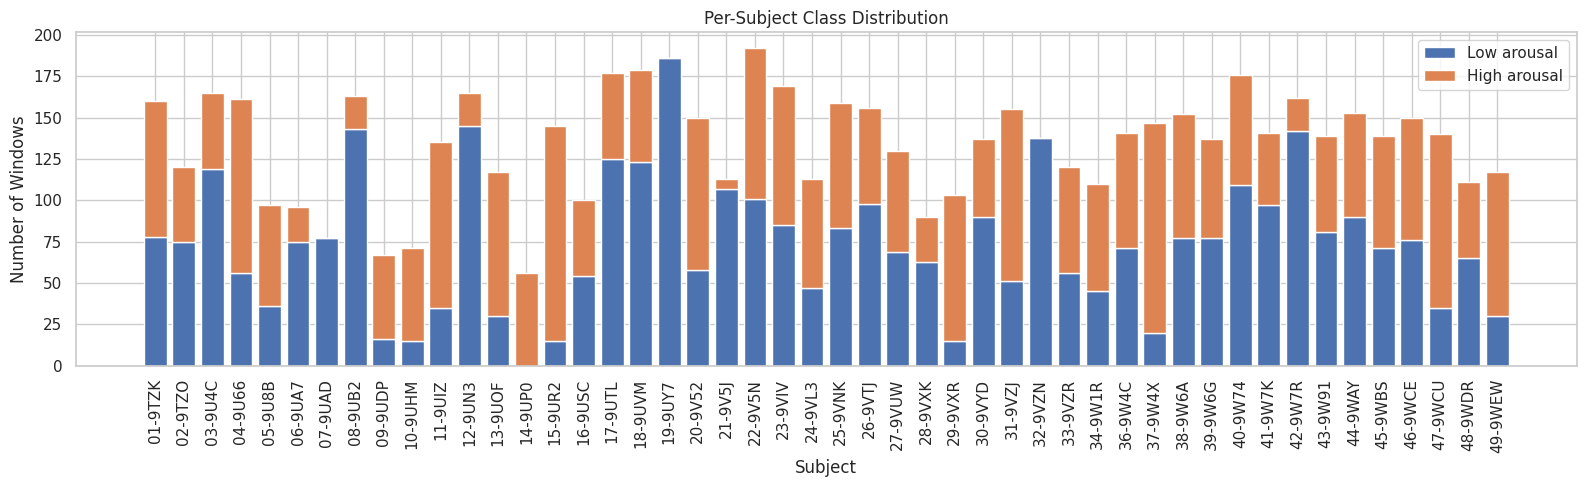

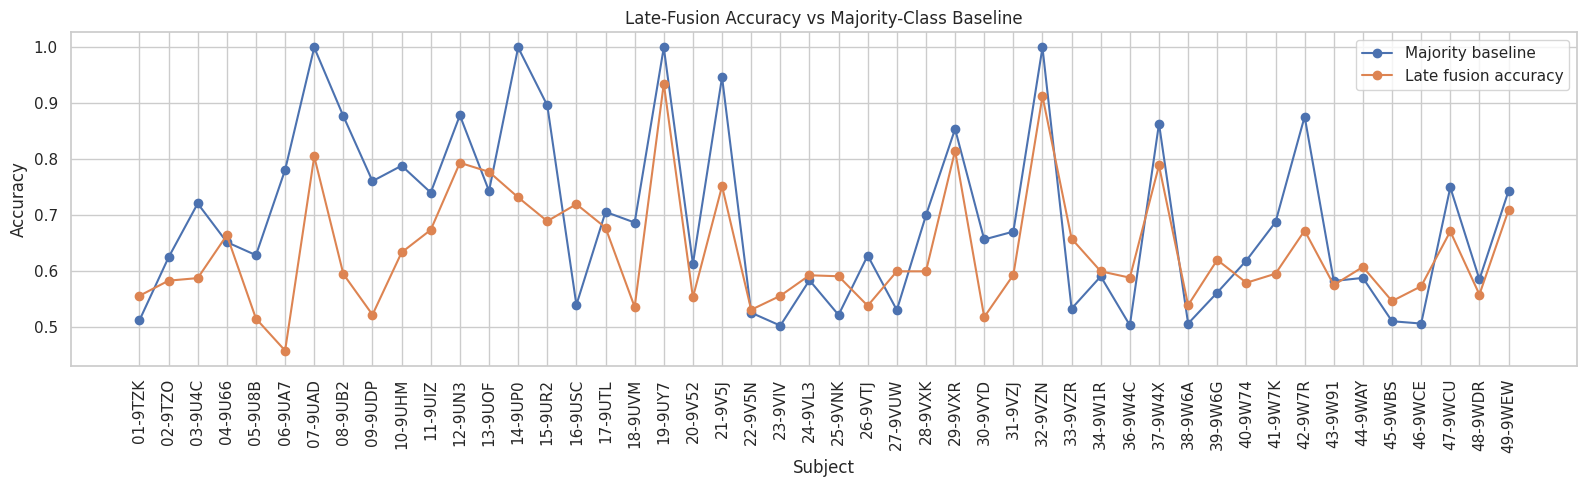

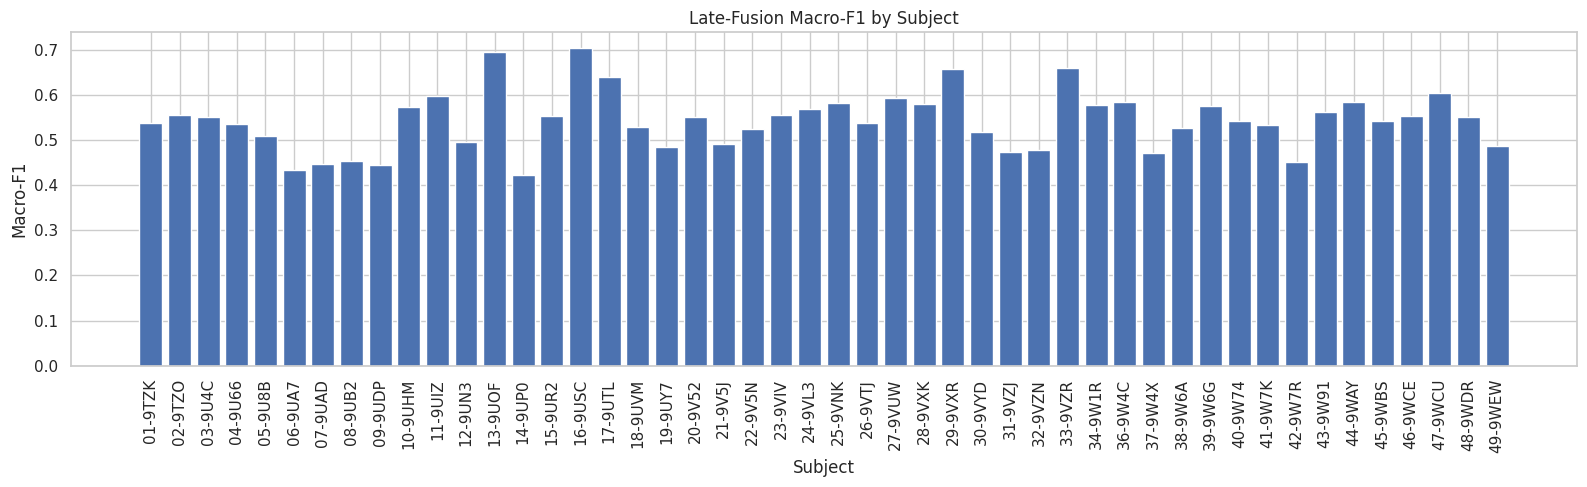

In [34]:
# ============================================================
# Cell 19B: Diagnostic Visualization
# ============================================================

plt.figure(figsize=(16, 5))
plt.bar(df_diag["Subject"], df_diag["Low_Arousal"], label="Low arousal")
plt.bar(df_diag["Subject"], df_diag["High_Arousal"], bottom=df_diag["Low_Arousal"], label="High arousal")
plt.xticks(rotation=90)
plt.title("Per-Subject Class Distribution")
plt.xlabel("Subject")
plt.ylabel("Number of Windows")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 5))
plt.plot(df_diag["Subject"], df_diag["Majority_Baseline_Acc"], marker="o", label="Majority baseline")
plt.plot(df_diag["Subject"], df_diag["LateFusion_Acc"], marker="o", label="Late fusion accuracy")
plt.xticks(rotation=90)
plt.title("Late-Fusion Accuracy vs Majority-Class Baseline")
plt.xlabel("Subject")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(16, 5))
plt.bar(df_diag["Subject"], df_diag["LateFusion_MacroF1"])
plt.xticks(rotation=90)
plt.title("Late-Fusion Macro-F1 by Subject")
plt.xlabel("Subject")
plt.ylabel("Macro-F1")
plt.tight_layout()
plt.show()

In [35]:
# ============================================================
# Cell 20: Stratified Group K-Fold Diagnostic
# ============================================================

from sklearn.model_selection import StratifiedGroupKFold

N_SPLITS = 5

sgkf = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED
)

fold_rows = []

for fold, (train_idx, test_idx) in enumerate(sgkf.split(X_fused, y, groups), start=1):
    y_train = y[train_idx]
    y_test = y[test_idx]

    train_subjects = np.unique(groups[train_idx])
    test_subjects = np.unique(groups[test_idx])

    train_low = np.sum(y_train == 0)
    train_high = np.sum(y_train == 1)

    test_low = np.sum(y_test == 0)
    test_high = np.sum(y_test == 1)

    majority_acc = max(test_low, test_high) / len(y_test)

    fold_rows.append({
        "Fold": fold,
        "Train_Subjects": len(train_subjects),
        "Test_Subjects": len(test_subjects),
        "Train_Samples": len(train_idx),
        "Test_Samples": len(test_idx),
        "Train_Low": train_low,
        "Train_High": train_high,
        "Test_Low": test_low,
        "Test_High": test_high,
        "Test_Majority_Baseline": majority_acc
    })

df_sgkf_diag = pd.DataFrame(fold_rows)

print("Stratified Group K-Fold diagnostic:")
print(df_sgkf_diag.to_string(index=False))

print("\nMean test majority baseline:")
print(df_sgkf_diag["Test_Majority_Baseline"].mean())

Stratified Group K-Fold diagnostic:
 Fold  Train_Subjects  Test_Subjects  Train_Samples  Test_Samples  Train_Low  Train_High  Test_Low  Test_High  Test_Majority_Baseline
    1              39              9           5217          1260       2832        2385       718        542                0.569841
    2              39              9           5255          1222       2971        2284       579        643                0.526187
    3              39              9           5240          1237       2803        2437       747        490                0.603880
    4              37             11           5088          1389       2794        2294       756        633                0.544276
    5              38             10           5108          1369       2800        2308       750        619                0.547845

Mean test majority baseline:
0.5584059610483435


In [36]:
# ============================================================
# Cell 21: Stratified Group K-Fold Training - Late Fusion Model
# ============================================================

import copy
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

EPOCHS = 50
BATCH_SIZE = 64
LR = 5e-4
PATIENCE = 8
N_SPLITS = 5

X_tensor = torch.tensor(X_fused, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

outer_cv = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED
)

sgkf_acc = []
sgkf_f1 = []

all_test_preds = []
all_test_targets = []

for fold, (trainval_idx, test_idx) in enumerate(outer_cv.split(X_fused, y, groups), start=1):

    print(f"\nFold {fold}/{N_SPLITS}")

    X_trainval = X_fused[trainval_idx]
    y_trainval = y[trainval_idx]
    groups_trainval = groups[trainval_idx]

    inner_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=SEED + fold
    )

    inner_train_rel, val_rel = next(inner_cv.split(X_trainval, y_trainval, groups_trainval))

    train_idx = trainval_idx[inner_train_rel]
    val_idx = trainval_idx[val_rel]

    train_ds = TensorDataset(X_tensor[train_idx], y_tensor[train_idx])
    val_ds = TensorDataset(X_tensor[val_idx], y_tensor[val_idx])
    test_ds = TensorDataset(X_tensor[test_idx], y_tensor[test_idx])

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = LateFusionCNNBiLSTM().to(device)

    class_counts = np.bincount(y[train_idx], minlength=2)
    class_weights = len(train_idx) / (2.0 * class_counts)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=3
    )

    best_val_f1 = 0.0
    best_state = None
    patience_counter = 0

    for epoch in range(1, EPOCHS + 1):

        model.train()
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=3.0)
            optimizer.step()

        model.eval()
        val_preds = []
        val_targets = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                logits = model(xb)
                preds = logits.argmax(dim=1).cpu().numpy()

                val_preds.extend(preds)
                val_targets.extend(yb.numpy())

        val_f1 = f1_score(val_targets, val_preds, average="macro", zero_division=0)
        scheduler.step(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            break

    model.load_state_dict(best_state)
    model.eval()

    test_preds = []
    test_targets = []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            logits = model(xb)
            preds = logits.argmax(dim=1).cpu().numpy()

            test_preds.extend(preds)
            test_targets.extend(yb.numpy())

    test_acc = accuracy_score(test_targets, test_preds)
    test_f1 = f1_score(test_targets, test_preds, average="macro", zero_division=0)

    sgkf_acc.append(test_acc)
    sgkf_f1.append(test_f1)

    all_test_preds.extend(test_preds)
    all_test_targets.extend(test_targets)

    print("Best validation Macro-F1:", best_val_f1)
    print("Test Accuracy:", test_acc)
    print("Test Macro-F1:", test_f1)

print("\nFinal Stratified Group K-Fold Results:")
print("Mean Accuracy:", np.mean(sgkf_acc))
print("Mean Macro-F1:", np.mean(sgkf_f1))

print("\nAggregate Results:")
print("Aggregate Accuracy:", accuracy_score(all_test_targets, all_test_preds))
print("Aggregate Macro-F1:", f1_score(all_test_targets, all_test_preds, average="macro", zero_division=0))


Fold 1/5
Best validation Macro-F1: 0.5732695549829818
Test Accuracy: 0.430952380952381
Test Macro-F1: 0.40205351747435747

Fold 2/5
Best validation Macro-F1: 0.5552049195792
Test Accuracy: 0.41080196399345337
Test Macro-F1: 0.4052563270603504

Fold 3/5
Best validation Macro-F1: 0.4323724669015734
Test Accuracy: 0.5812449474535166
Test Macro-F1: 0.4507217802770539

Fold 4/5
Best validation Macro-F1: 0.5565793065793065
Test Accuracy: 0.42836573074154066
Test Macro-F1: 0.427532244803043

Fold 5/5
Best validation Macro-F1: 0.5566231030686007
Test Accuracy: 0.5113221329437546
Test Macro-F1: 0.5100411339026493

Final Stratified Group K-Fold Results:
Mean Accuracy: 0.47253743121692926
Mean Macro-F1: 0.4391210007034908

Aggregate Results:
Aggregate Accuracy: 0.47228655241624207
Aggregate Macro-F1: 0.45900096438764515


In [37]:
# ============================================================
# Cell 22: Timestamp-Aware Full Dataset Reconstruction
# ============================================================

TARGET_FS = 25
WINDOW_SEC = 10
WINDOW_SIZE = TARGET_FS * WINDOW_SEC

def interpolate_to_common_time(timestamps, values, common_time):
    return np.interp(common_time, timestamps, values)

def process_subject_timestamp_aware(subj_id):
    subj_path = os.path.join(DATASET_ROOT, subj_id)

    resp_df = pd.read_csv(os.path.join(subj_path, "signals-bh3-rsp.csv"))
    ecg_df  = pd.read_csv(os.path.join(subj_path, "signals-bh3-ecg.csv"))
    eda_df  = pd.read_csv(os.path.join(subj_path, "signals-e4-eda.csv"))

    surveys_df = pd.read_csv(os.path.join(subj_path, "surveys.csv"))
    markers_df = pd.read_csv(os.path.join(subj_path, "markers-phase2.csv"))

    resp_t = resp_df["timestamp"].values
    ecg_t  = ecg_df["timestamp"].values
    eda_t  = eda_df["timestamp"].values

    resp_v = resp_df["value"].values
    ecg_v  = ecg_df["value"].values
    eda_v  = eda_df["value"].values

    resp_f = preprocess_respiration(resp_v, FS_RESP)
    ecg_f  = preprocess_ecg(ecg_v, FS_ECG)
    eda_f  = preprocess_eda(eda_v, FS_EDA)

    common_start = max(resp_t[0], ecg_t[0], eda_t[0])
    common_end   = min(resp_t[-1], ecg_t[-1], eda_t[-1])

    common_time = np.arange(common_start, common_end, 1.0 / TARGET_FS)

    resp_common = interpolate_to_common_time(resp_t, resp_f, common_time)
    ecg_common  = interpolate_to_common_time(ecg_t,  ecg_f,  common_time)
    eda_common  = interpolate_to_common_time(eda_t,  eda_f,  common_time)

    resp_common = zscore_normalize(resp_common)
    ecg_common  = zscore_normalize(ecg_common)
    eda_common  = zscore_normalize(eda_common)

    num_windows = len(common_time) // WINDOW_SIZE

    stimulus_segments = markers_df[["exp", "vidB", "postB"]].copy()
    stimulus_segments.columns = ["exp", "start_time", "end_time"]

    survey_lookup = surveys_df.set_index("exp")

    X_resp_subj = []
    X_ecg_subj = []
    X_eda_subj = []
    y_subj = []

    for i in range(num_windows):
        start_idx = i * WINDOW_SIZE
        end_idx = start_idx + WINDOW_SIZE

        ws = common_time[start_idx]
        we = common_time[end_idx - 1]

        match = stimulus_segments[
            (stimulus_segments["start_time"] <= ws) &
            (stimulus_segments["end_time"] >= we)
        ]

        if len(match) != 1:
            continue

        exp_id = int(match.iloc[0]["exp"])

        if exp_id not in survey_lookup.index:
            continue

        arousal = survey_lookup.loc[exp_id]["arousal"]

        if arousal <= 4:
            label = 0
        elif arousal >= 6:
            label = 1
        else:
            continue

        X_resp_subj.append(resp_common[start_idx:end_idx])
        X_ecg_subj.append(ecg_common[start_idx:end_idx])
        X_eda_subj.append(eda_common[start_idx:end_idx])
        y_subj.append(label)

    return X_resp_subj, X_ecg_subj, X_eda_subj, y_subj


X_resp_all_fixed = []
X_ecg_all_fixed = []
X_eda_all_fixed = []
y_all_fixed = []
groups_all_fixed = []

subject_ids = sorted(os.listdir(DATASET_ROOT))

for subj_id in subject_ids:
    try:
        xr, xe, xd, yy = process_subject_timestamp_aware(subj_id)

        X_resp_all_fixed.extend(xr)
        X_ecg_all_fixed.extend(xe)
        X_eda_all_fixed.extend(xd)
        y_all_fixed.extend(yy)
        groups_all_fixed.extend([subj_id] * len(yy))

        print(subj_id, "samples:", len(yy),
              "low:", np.sum(np.array(yy) == 0),
              "high:", np.sum(np.array(yy) == 1))

    except Exception as e:
        print(subj_id, "failed:", str(e))


X_resp = np.array(X_resp_all_fixed)
X_ecg  = np.array(X_ecg_all_fixed)
X_eda  = np.array(X_eda_all_fixed)

y = np.array(y_all_fixed)
groups = np.array(groups_all_fixed)

X_fused = np.stack([X_resp, X_ecg, X_eda], axis=1)

print("\nTimestamp-aware dataset complete")
print("X_resp:", X_resp.shape)
print("X_ecg :", X_ecg.shape)
print("X_eda :", X_eda.shape)
print("X_fused:", X_fused.shape)
print("y:", y.shape)
print("groups:", groups.shape)

print("\nClass distribution")
print("Low arousal:", np.sum(y == 0))
print("High arousal:", np.sum(y == 1))

01-9TZK samples: 156 low: 74 high: 82
02-9TZO samples: 122 low: 76 high: 46
03-9U4C samples: 165 low: 118 high: 47
04-9U66 samples: 169 low: 57 high: 112
05-9U8B samples: 97 low: 36 high: 61
06-9UA7 samples: 98 low: 76 high: 22
07-9UAD samples: 79 low: 79 high: 0
08-9UB2 samples: 165 low: 145 high: 20
09-9UDP samples: 65 low: 15 high: 50
10-9UHM samples: 73 low: 15 high: 58
11-9UIZ samples: 133 low: 37 high: 96
12-9UN3 samples: 163 low: 142 high: 21
13-9UOF samples: 110 low: 30 high: 80
14-9UP0 samples: 56 low: 0 high: 56
15-9UR2 samples: 144 low: 15 high: 129
16-9USC samples: 105 low: 57 high: 48
17-9UTL samples: 170 low: 119 high: 51
18-9UVM samples: 179 low: 123 high: 56
19-9UY7 samples: 187 low: 187 high: 0
20-9V52 samples: 149 low: 56 high: 93
21-9V5J samples: 116 low: 110 high: 6
22-9V5N samples: 190 low: 102 high: 88
23-9VIV samples: 166 low: 86 high: 80
24-9VL3 samples: 110 low: 47 high: 63
25-9VNK samples: 158 low: 79 high: 79
26-9VTJ samples: 155 low: 97 high: 58
27-9VUW samp

In [38]:
# ============================================================
# Cell 23: Stratified Group K-Fold Diagnostic After Timestamp Fix
# ============================================================

from sklearn.model_selection import StratifiedGroupKFold

N_SPLITS = 5

sgkf = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED
)

fold_rows = []

for fold, (train_idx, test_idx) in enumerate(sgkf.split(X_fused, y, groups), start=1):
    y_train = y[train_idx]
    y_test = y[test_idx]

    train_subjects = np.unique(groups[train_idx])
    test_subjects = np.unique(groups[test_idx])

    train_low = np.sum(y_train == 0)
    train_high = np.sum(y_train == 1)

    test_low = np.sum(y_test == 0)
    test_high = np.sum(y_test == 1)

    majority_acc = max(test_low, test_high) / len(y_test)

    fold_rows.append({
        "Fold": fold,
        "Train_Subjects": len(train_subjects),
        "Test_Subjects": len(test_subjects),
        "Train_Samples": len(train_idx),
        "Test_Samples": len(test_idx),
        "Train_Low": train_low,
        "Train_High": train_high,
        "Test_Low": test_low,
        "Test_High": test_high,
        "Test_Majority_Baseline": majority_acc
    })

df_sgkf_diag_fixed = pd.DataFrame(fold_rows)

print("Stratified Group K-Fold diagnostic after timestamp fix:")
print(df_sgkf_diag_fixed.to_string(index=False))

print("\nMean test majority baseline:")
print(df_sgkf_diag_fixed["Test_Majority_Baseline"].mean())

Stratified Group K-Fold diagnostic after timestamp fix:
 Fold  Train_Subjects  Test_Subjects  Train_Samples  Test_Samples  Train_Low  Train_High  Test_Low  Test_High  Test_Majority_Baseline
    1              38             10           5025          1475       2838        2187       727        748                0.507119
    2              38             10           5080          1420       2820        2260       745        675                0.524648
    3              38             10           5318          1182       2922        2396       643        539                0.543993
    4              38             10           5140          1360       2755        2385       810        550                0.595588
    5              40              8           5437          1063       2925        2512       640        423                0.602070

Mean test majority baseline:
0.5546835225591004


In [39]:
# ============================================================
# Cell 24: Timestamp-Aware Stratified Group K-Fold Training
# Late-Fusion CNN-BiLSTM
# ============================================================

import copy
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

EPOCHS = 60
BATCH_SIZE = 64
LR = 5e-4
PATIENCE = 10
N_SPLITS = 5

X_tensor = torch.tensor(X_fused, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

outer_cv = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED
)

latefusion_acc = []
latefusion_f1 = []

all_test_preds = []
all_test_targets = []

for fold, (trainval_idx, test_idx) in enumerate(outer_cv.split(X_fused, y, groups), start=1):

    print(f"\nFold {fold}/{N_SPLITS}")

    X_trainval = X_fused[trainval_idx]
    y_trainval = y[trainval_idx]
    groups_trainval = groups[trainval_idx]

    inner_cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=SEED + fold
    )

    inner_train_rel, val_rel = next(inner_cv.split(X_trainval, y_trainval, groups_trainval))

    train_idx = trainval_idx[inner_train_rel]
    val_idx = trainval_idx[val_rel]

    train_ds = TensorDataset(X_tensor[train_idx], y_tensor[train_idx])
    val_ds = TensorDataset(X_tensor[val_idx], y_tensor[val_idx])
    test_ds = TensorDataset(X_tensor[test_idx], y_tensor[test_idx])

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

    model = LateFusionCNNBiLSTM().to(device)

    class_counts = np.bincount(y[train_idx], minlength=2)
    class_weights = len(train_idx) / (2.0 * class_counts)
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=3
    )

    best_val_f1 = 0.0
    best_state = None
    patience_counter = 0

    for epoch in range(1, EPOCHS + 1):

        model.train()

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=3.0)

            optimizer.step()

        model.eval()

        val_preds = []
        val_targets = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                logits = model(xb)
                preds = logits.argmax(dim=1).cpu().numpy()

                val_preds.extend(preds)
                val_targets.extend(yb.numpy())

        val_f1 = f1_score(val_targets, val_preds, average="macro", zero_division=0)
        scheduler.step(val_f1)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= PATIENCE:
            break

    model.load_state_dict(best_state)
    model.eval()

    test_preds = []
    test_targets = []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            logits = model(xb)
            preds = logits.argmax(dim=1).cpu().numpy()

            test_preds.extend(preds)
            test_targets.extend(yb.numpy())

    test_acc = accuracy_score(test_targets, test_preds)
    test_f1 = f1_score(test_targets, test_preds, average="macro", zero_division=0)

    latefusion_acc.append(test_acc)
    latefusion_f1.append(test_f1)

    all_test_preds.extend(test_preds)
    all_test_targets.extend(test_targets)

    print("Best validation Macro-F1:", best_val_f1)
    print("Test Accuracy:", test_acc)
    print("Test Macro-F1:", test_f1)

print("\nFinal Timestamp-Aware Late-Fusion Results:")
print("Mean Accuracy:", np.mean(latefusion_acc))
print("Mean Macro-F1:", np.mean(latefusion_f1))

print("\nAggregate Results:")
print("Aggregate Accuracy:", accuracy_score(all_test_targets, all_test_preds))
print("Aggregate Macro-F1:", f1_score(all_test_targets, all_test_preds, average="macro", zero_division=0))

print("\nClassification Report:")
print(classification_report(all_test_targets, all_test_preds, target_names=["Low Arousal", "High Arousal"]))


Fold 1/5
Best validation Macro-F1: 0.4964165155069835
Test Accuracy: 0.5240677966101694
Test Macro-F1: 0.523584072262282

Fold 2/5
Best validation Macro-F1: 0.4995103933313061
Test Accuracy: 0.5105633802816901
Test Macro-F1: 0.5100266062155973

Fold 3/5
Best validation Macro-F1: 0.5184531648078982
Test Accuracy: 0.44247038917089676
Test Macro-F1: 0.43750988407737423

Fold 4/5
Best validation Macro-F1: 0.5380991318925445
Test Accuracy: 0.5441176470588235
Test Macro-F1: 0.5037244210902996

Fold 5/5
Best validation Macro-F1: 0.5456389199396107
Test Accuracy: 0.51552210724365
Test Macro-F1: 0.44955230783926314

Final Timestamp-Aware Late-Fusion Results:
Mean Accuracy: 0.5073482640730459
Mean Macro-F1: 0.4848794582969632

Aggregate Results:
Aggregate Accuracy: 0.5090769230769231
Aggregate Macro-F1: 0.5041948559753168

Classification Report:
              precision    recall  f1-score   support

 Low Arousal       0.55      0.55      0.55      3565
High Arousal       0.46      0.45      0.4

In [40]:
# ============================================================
# Cell 25: Stimulus-Level Physiological Feature Dataset
# ============================================================

from scipy.signal import find_peaks, welch
from scipy.stats import skew, kurtosis
from scipy.integrate import trapezoid

def spectral_entropy(x, fs):
    freqs, psd = welch(x, fs=fs, nperseg=min(len(x), 256))
    psd = psd / (np.sum(psd) + 1e-8)
    return -np.sum(psd * np.log2(psd + 1e-8))

def band_power(x, fs, low, high):
    freqs, psd = welch(x, fs=fs, nperseg=min(len(x), 256))
    mask = (freqs >= low) & (freqs <= high)
    if np.sum(mask) == 0:
        return 0.0
    return trapezoid(psd[mask], freqs[mask])

def extract_resp_features(x, fs=25):
    if len(x) < fs * 10:
        return None

    peaks, _ = find_peaks(
        x,
        distance=int(fs * 1.5),
        prominence=np.std(x) * 0.15
    )

    ibi = np.diff(peaks) / fs if len(peaks) > 1 else np.array([0.0])

    return {
        "resp_mean": np.mean(x),
        "resp_std": np.std(x),
        "resp_rms": np.sqrt(np.mean(x ** 2)),
        "resp_skew": skew(x),
        "resp_kurtosis": kurtosis(x),
        "resp_rate": (len(peaks) / (len(x) / fs)) * 60,
        "resp_ibi_mean": np.mean(ibi),
        "resp_ibi_std": np.std(ibi),
        "resp_bandpower": band_power(x, fs, 0.1, 0.5),
        "resp_entropy": spectral_entropy(x, fs)
    }

def extract_ecg_features(x, fs=250):
    if len(x) < fs * 10:
        return None

    peaks, _ = find_peaks(
        x,
        distance=int(fs * 0.35),
        prominence=np.std(x) * 0.4
    )

    rr = np.diff(peaks) / fs if len(peaks) > 2 else np.array([0.0])
    hr = 60 / (rr + 1e-8) if len(rr) > 1 else np.array([0.0])

    rmssd = np.sqrt(np.mean(np.diff(rr) ** 2)) if len(rr) > 2 else 0.0
    pnn50 = np.mean(np.abs(np.diff(rr)) > 0.05) if len(rr) > 2 else 0.0

    return {
        "ecg_mean": np.mean(x),
        "ecg_std": np.std(x),
        "ecg_rms": np.sqrt(np.mean(x ** 2)),
        "ecg_skew": skew(x),
        "ecg_kurtosis": kurtosis(x),
        "ecg_hr_mean": np.mean(hr),
        "ecg_hr_std": np.std(hr),
        "ecg_rr_mean": np.mean(rr),
        "ecg_rr_std": np.std(rr),
        "ecg_rmssd": rmssd,
        "ecg_pnn50": pnn50,
        "ecg_entropy": spectral_entropy(x, fs)
    }

def extract_eda_features(x, fs=4):
    if len(x) < fs * 10:
        return None

    t = np.arange(len(x)) / fs
    slope = np.polyfit(t, x, 1)[0] if len(x) > 2 else 0.0

    peaks, props = find_peaks(
        x,
        distance=int(fs * 1.0),
        prominence=np.std(x) * 0.1
    )

    return {
        "eda_mean": np.mean(x),
        "eda_std": np.std(x),
        "eda_min": np.min(x),
        "eda_max": np.max(x),
        "eda_range": np.max(x) - np.min(x),
        "eda_slope": slope,
        "eda_auc": trapezoid(x, t),
        "eda_peak_count": len(peaks),
        "eda_entropy": spectral_entropy(x, fs)
    }

feature_rows = []

subject_ids = sorted(os.listdir(DATASET_ROOT))

for subj_id in subject_ids:
    subj_path = os.path.join(DATASET_ROOT, subj_id)

    try:
        resp_df = pd.read_csv(os.path.join(subj_path, "signals-bh3-rsp.csv"))
        ecg_df  = pd.read_csv(os.path.join(subj_path, "signals-bh3-ecg.csv"))
        eda_df  = pd.read_csv(os.path.join(subj_path, "signals-e4-eda.csv"))

        surveys_df = pd.read_csv(os.path.join(subj_path, "surveys.csv"))
        markers_df = pd.read_csv(os.path.join(subj_path, "markers-phase2.csv"))

        resp_t, resp_v = resp_df["timestamp"].values, resp_df["value"].values
        ecg_t,  ecg_v  = ecg_df["timestamp"].values,  ecg_df["value"].values
        eda_t,  eda_v  = eda_df["timestamp"].values,  eda_df["value"].values

        resp_f = preprocess_respiration(resp_v, FS_RESP)
        ecg_f  = preprocess_ecg(ecg_v, FS_ECG)
        eda_f  = preprocess_eda(eda_v, FS_EDA)

        survey_lookup = surveys_df.set_index("exp")

        for _, row in markers_df.iterrows():
            exp_id = int(row["exp"])
            start = row["vidB"]
            end = row["postB"]

            if exp_id not in survey_lookup.index:
                continue

            arousal = survey_lookup.loc[exp_id]["arousal"]

            if arousal <= 4:
                label = 0
            elif arousal >= 6:
                label = 1
            else:
                continue

            resp_seg = resp_f[(resp_t >= start) & (resp_t <= end)]
            ecg_seg  = ecg_f[(ecg_t >= start) & (ecg_t <= end)]
            eda_seg  = eda_f[(eda_t >= start) & (eda_t <= end)]

            resp_feat = extract_resp_features(resp_seg, FS_RESP)
            ecg_feat  = extract_ecg_features(ecg_seg, FS_ECG)
            eda_feat  = extract_eda_features(eda_seg, FS_EDA)

            if resp_feat is None or ecg_feat is None or eda_feat is None:
                continue

            feature_row = {
                "Subject": subj_id,
                "exp": exp_id,
                "valence": survey_lookup.loc[exp_id]["valence"],
                "arousal": arousal,
                "label": label
            }

            feature_row.update(resp_feat)
            feature_row.update(ecg_feat)
            feature_row.update(eda_feat)

            feature_rows.append(feature_row)

    except Exception as e:
        print(subj_id, "failed:", str(e))

df_features = pd.DataFrame(feature_rows)

print("Stimulus-level feature dataset created")
print("Shape:", df_features.shape)

print("\nClass distribution:")
print(df_features["label"].value_counts().sort_index())

print("\nSubjects:", df_features["Subject"].nunique())

print("\nPreview:")
print(df_features.head())

Stimulus-level feature dataset created
Shape: (1265, 36)

Class distribution:
label
0    696
1    569
Name: count, dtype: int64

Subjects: 48

Preview:
   Subject  exp  valence  arousal  label  resp_mean    resp_std    resp_rms  \
0  01-9TZK    7      6.4      7.7      1  -1.620059  580.980848  580.983107   
1  01-9TZK    4      5.0      3.0      0  14.142243  794.791996  794.917807   
2  01-9TZK   40      3.0      3.1      0   5.189730  809.228976  809.245617   
3  01-9TZK   17      3.0      2.9      0 -16.987888  662.396229  662.614030   
4  01-9TZK    2      1.7      6.4      1   8.014770  943.409087  943.443131   

   resp_skew  resp_kurtosis  ...  ecg_entropy  eda_mean   eda_std   eda_min  \
0  -0.035328      -1.265956  ...     4.478487  0.629063  0.025909  0.574030   
1   0.045758      -1.124471  ...     4.539657  0.617086  0.045246  0.536010   
2  -0.037642      -1.120071  ...     4.519063  0.451961  0.033490  0.394800   
3  -0.023165      -1.072151  ...     4.505392  0.323436  

In [41]:
# ============================================================
# Cell 26: Feature Dataset Quality Check
# ============================================================

# Identify feature columns
non_feature_cols = ["Subject", "exp", "valence", "arousal", "label"]
feature_cols = [c for c in df_features.columns if c not in non_feature_cols]

print("Number of feature columns:", len(feature_cols))
print("\nFeature columns:")
for col in feature_cols:
    print(col)

# Check missing and infinite values
missing_count = df_features[feature_cols].isna().sum().sum()
inf_count = np.isinf(df_features[feature_cols].values).sum()

print("\nMissing values:", missing_count)
print("Infinite values:", inf_count)

# Replace inf with nan, then drop rows with nan if any
df_features_clean = df_features.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)

print("\nOriginal shape:", df_features.shape)
print("Clean shape:", df_features_clean.shape)

# Build arrays
X_feat = df_features_clean[feature_cols].values
y_feat = df_features_clean["label"].values.astype(int)
groups_feat = df_features_clean["Subject"].values

print("\nFinal feature matrix:")
print("X_feat:", X_feat.shape)
print("y_feat:", y_feat.shape)
print("groups_feat:", groups_feat.shape)

print("\nClass distribution:")
print(pd.Series(y_feat).value_counts().sort_index())

print("\nNumber of subjects:", len(np.unique(groups_feat)))

Number of feature columns: 31

Feature columns:
resp_mean
resp_std
resp_rms
resp_skew
resp_kurtosis
resp_rate
resp_ibi_mean
resp_ibi_std
resp_bandpower
resp_entropy
ecg_mean
ecg_std
ecg_rms
ecg_skew
ecg_kurtosis
ecg_hr_mean
ecg_hr_std
ecg_rr_mean
ecg_rr_std
ecg_rmssd
ecg_pnn50
ecg_entropy
eda_mean
eda_std
eda_min
eda_max
eda_range
eda_slope
eda_auc
eda_peak_count
eda_entropy

Missing values: 0
Infinite values: 0

Original shape: (1265, 36)
Clean shape: (1265, 36)

Final feature matrix:
X_feat: (1265, 31)
y_feat: (1265,)
groups_feat: (1265,)

Class distribution:
0    696
1    569
Name: count, dtype: int64

Number of subjects: 48


In [42]:
# ============================================================
# Cell 27: Feature-Based ML with Stratified Group K-Fold
# ============================================================

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except:
    XGB_AVAILABLE = False

N_SPLITS = 5

cv = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED
)

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=SEED
        ))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(
            kernel="rbf",
            C=10,
            gamma="scale",
            class_weight="balanced",
            probability=True,
            random_state=SEED
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1
    )
}

if XGB_AVAILABLE:
    models["XGBoost"] = XGBClassifier(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=3,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=SEED,
        n_jobs=-1
    )

results = []
all_predictions = {}
all_targets = {}

for model_name, model in models.items():
    fold_acc = []
    fold_f1 = []

    preds_all = []
    targets_all = []

    print("\nModel:", model_name)

    for fold, (train_idx, test_idx) in enumerate(cv.split(X_feat, y_feat, groups_feat), start=1):
        X_train, X_test = X_feat[train_idx], X_feat[test_idx]
        y_train, y_test = y_feat[train_idx], y_feat[test_idx]

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds, average="macro", zero_division=0)

        fold_acc.append(acc)
        fold_f1.append(f1)

        preds_all.extend(preds)
        targets_all.extend(y_test)

        print(f"Fold {fold}: Acc={acc:.4f}, Macro-F1={f1:.4f}")

    aggregate_acc = accuracy_score(targets_all, preds_all)
    aggregate_f1 = f1_score(targets_all, preds_all, average="macro", zero_division=0)

    results.append({
        "Model": model_name,
        "Mean_Accuracy": np.mean(fold_acc),
        "Std_Accuracy": np.std(fold_acc),
        "Mean_MacroF1": np.mean(fold_f1),
        "Std_MacroF1": np.std(fold_f1),
        "Aggregate_Accuracy": aggregate_acc,
        "Aggregate_MacroF1": aggregate_f1
    })

    all_predictions[model_name] = np.array(preds_all)
    all_targets[model_name] = np.array(targets_all)

df_ml_results = pd.DataFrame(results).sort_values(
    by="Aggregate_MacroF1",
    ascending=False
).reset_index(drop=True)

print("\nFeature-Based ML Results:")
print(df_ml_results.to_string(index=False))


Model: Logistic Regression
Fold 1: Acc=0.5446, Macro-F1=0.5429
Fold 2: Acc=0.5263, Macro-F1=0.5201
Fold 3: Acc=0.4816, Macro-F1=0.4796
Fold 4: Acc=0.4559, Macro-F1=0.4536
Fold 5: Acc=0.5249, Macro-F1=0.5233

Model: SVM
Fold 1: Acc=0.6875, Macro-F1=0.6874
Fold 2: Acc=0.5668, Macro-F1=0.5498
Fold 3: Acc=0.4522, Macro-F1=0.4521
Fold 4: Acc=0.4521, Macro-F1=0.4509
Fold 5: Acc=0.5517, Macro-F1=0.5301

Model: Random Forest
Fold 1: Acc=0.5312, Macro-F1=0.5035
Fold 2: Acc=0.5749, Macro-F1=0.5536
Fold 3: Acc=0.5147, Macro-F1=0.5134
Fold 4: Acc=0.4904, Macro-F1=0.4694
Fold 5: Acc=0.5326, Macro-F1=0.5207

Model: Extra Trees
Fold 1: Acc=0.4777, Macro-F1=0.4700
Fold 2: Acc=0.5466, Macro-F1=0.5171
Fold 3: Acc=0.5441, Macro-F1=0.5429
Fold 4: Acc=0.4406, Macro-F1=0.4126
Fold 5: Acc=0.5747, Macro-F1=0.5375

Model: XGBoost
Fold 1: Acc=0.4911, Macro-F1=0.4743
Fold 2: Acc=0.5425, Macro-F1=0.5326
Fold 3: Acc=0.5184, Macro-F1=0.5128
Fold 4: Acc=0.4943, Macro-F1=0.4870
Fold 5: Acc=0.5326, Macro-F1=0.5282

F

In [43]:
# ============================================================
# Cell 28: Label Strategy Diagnostic
# ============================================================

df_label_diag = df_features_clean.copy()

print("Original stimulus-level dataset:")
print("Shape:", df_label_diag.shape)

print("\nArousal summary:")
print(df_label_diag["arousal"].describe())

print("\nValence summary:")
print(df_label_diag["valence"].describe())

# Strategy A: Current arousal-only
strategy_a = df_label_diag[
    (df_label_diag["arousal"] <= 4) | (df_label_diag["arousal"] >= 6)
].copy()
strategy_a["label_strategy"] = np.where(strategy_a["arousal"] <= 4, 0, 1)

# Strategy B: Extreme arousal only
strategy_b = df_label_diag[
    (df_label_diag["arousal"] <= 3) | (df_label_diag["arousal"] >= 7)
].copy()
strategy_b["label_strategy"] = np.where(strategy_b["arousal"] <= 3, 0, 1)

# Strategy C: Valence-arousal contrast
# Class 0 = positive calm / pleasant low arousal
# Class 1 = negative high arousal
strategy_c = df_label_diag[
    ((df_label_diag["valence"] >= 6) & (df_label_diag["arousal"] <= 4)) |
    ((df_label_diag["valence"] <= 4) & (df_label_diag["arousal"] >= 6))
].copy()

strategy_c["label_strategy"] = np.where(
    (strategy_c["valence"] >= 6) & (strategy_c["arousal"] <= 4),
    0,
    1
)

# Strategy D: Valence-only extreme
strategy_d = df_label_diag[
    (df_label_diag["valence"] <= 4) | (df_label_diag["valence"] >= 6)
].copy()
strategy_d["label_strategy"] = np.where(strategy_d["valence"] <= 4, 0, 1)

strategies = {
    "A_current_arousal_4_6": strategy_a,
    "B_extreme_arousal_3_7": strategy_b,
    "C_valence_arousal_contrast": strategy_c,
    "D_extreme_valence_4_6": strategy_d
}

summary_rows = []

for name, df_s in strategies.items():
    if len(df_s) == 0:
        continue

    class_counts = df_s["label_strategy"].value_counts().sort_index()
    subjects_count = df_s["Subject"].nunique()

    n0 = class_counts.get(0, 0)
    n1 = class_counts.get(1, 0)

    summary_rows.append({
        "Strategy": name,
        "Samples": len(df_s),
        "Subjects": subjects_count,
        "Class_0": n0,
        "Class_1": n1,
        "Class_Balance_Ratio": min(n0, n1) / max(n0, n1) if max(n0, n1) > 0 else 0
    })

df_strategy_summary = pd.DataFrame(summary_rows)

print("\nLabel strategy summary:")
print(df_strategy_summary.to_string(index=False))

Original stimulus-level dataset:
Shape: (1265, 36)

Arousal summary:
count    1265.000000
mean        4.550198
std         2.260745
min         1.000000
25%         2.800000
50%         3.800000
75%         6.600000
max         9.000000
Name: arousal, dtype: float64

Valence summary:
count    1265.000000
mean        5.293123
std         2.153653
min         1.000000
25%         3.700000
50%         5.100000
75%         7.000000
max         9.000000
Name: valence, dtype: float64

Label strategy summary:
                  Strategy  Samples  Subjects  Class_0  Class_1  Class_Balance_Ratio
     A_current_arousal_4_6     1265        48      696      569             0.817529
     B_extreme_arousal_3_7      634        48      415      219             0.527711
C_valence_arousal_contrast      468        47      251      217             0.864542
     D_extreme_valence_4_6      932        48      387      545             0.710092


In [44]:
# ============================================================
# Cell 29: Compare Feature-Based ML Across Label Strategies
# ============================================================

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, f1_score

def evaluate_strategy(df_strategy, strategy_name):
    X_s = df_strategy[feature_cols].values
    y_s = df_strategy["label_strategy"].values.astype(int)
    groups_s = df_strategy["Subject"].values

    cv = StratifiedGroupKFold(
        n_splits=5,
        shuffle=True,
        random_state=SEED
    )

    models = {
        "SVM": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(
                kernel="rbf",
                C=10,
                gamma="scale",
                class_weight="balanced",
                random_state=SEED
            ))
        ]),

        "Random Forest": RandomForestClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1
        ),

        "Extra Trees": ExtraTreesClassifier(
            n_estimators=500,
            max_depth=None,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=SEED,
            n_jobs=-1
        )
    }

    strategy_results = []

    for model_name, model in models.items():
        fold_acc = []
        fold_f1 = []

        all_preds = []
        all_targets = []

        for train_idx, test_idx in cv.split(X_s, y_s, groups_s):
            X_train, X_test = X_s[train_idx], X_s[test_idx]
            y_train, y_test = y_s[train_idx], y_s[test_idx]

            model.fit(X_train, y_train)
            preds = model.predict(X_test)

            fold_acc.append(accuracy_score(y_test, preds))
            fold_f1.append(f1_score(y_test, preds, average="macro", zero_division=0))

            all_preds.extend(preds)
            all_targets.extend(y_test)

        strategy_results.append({
            "Strategy": strategy_name,
            "Model": model_name,
            "Samples": len(df_strategy),
            "Subjects": df_strategy["Subject"].nunique(),
            "Mean_Accuracy": np.mean(fold_acc),
            "Mean_MacroF1": np.mean(fold_f1),
            "Aggregate_Accuracy": accuracy_score(all_targets, all_preds),
            "Aggregate_MacroF1": f1_score(all_targets, all_preds, average="macro", zero_division=0)
        })

    return strategy_results


all_strategy_results = []

for strategy_name, df_strategy in strategies.items():
    if len(df_strategy) < 100:
        continue

    print("\nEvaluating:", strategy_name)
    print("Samples:", len(df_strategy))
    print("Subjects:", df_strategy["Subject"].nunique())
    print("Class distribution:")
    print(df_strategy["label_strategy"].value_counts().sort_index())

    strategy_result = evaluate_strategy(df_strategy, strategy_name)
    all_strategy_results.extend(strategy_result)

df_strategy_ml_results = pd.DataFrame(all_strategy_results).sort_values(
    by="Aggregate_MacroF1",
    ascending=False
).reset_index(drop=True)

print("\nStrategy Comparison Results:")
print(df_strategy_ml_results.to_string(index=False))


Evaluating: A_current_arousal_4_6
Samples: 1265
Subjects: 48
Class distribution:
label_strategy
0    696
1    569
Name: count, dtype: int64

Evaluating: B_extreme_arousal_3_7
Samples: 634
Subjects: 48
Class distribution:
label_strategy
0    415
1    219
Name: count, dtype: int64

Evaluating: C_valence_arousal_contrast
Samples: 468
Subjects: 47
Class distribution:
label_strategy
0    251
1    217
Name: count, dtype: int64

Evaluating: D_extreme_valence_4_6
Samples: 932
Subjects: 48
Class distribution:
label_strategy
0    387
1    545
Name: count, dtype: int64

Strategy Comparison Results:
                  Strategy         Model  Samples  Subjects  Mean_Accuracy  Mean_MacroF1  Aggregate_Accuracy  Aggregate_MacroF1
     A_current_arousal_4_6           SVM     1265        48       0.542068      0.534076            0.536759           0.532899
     D_extreme_valence_4_6 Random Forest      932        48       0.568719      0.518028            0.566524           0.523517
     A_current_arous

In [45]:
# ============================================================
# Cell 30: Inspect Global Metadata and Label Sources
# ============================================================

meta_path = os.path.join(DATASET_PATH, "meta.csv")
questionnaire_path = os.path.join(DATASET_PATH, "questionnaire.csv")

meta_df = pd.read_csv(meta_path)
questionnaire_df = pd.read_csv(questionnaire_path)

print("Global meta.csv")
print("Shape:", meta_df.shape)
print("Columns:")
for col in meta_df.columns:
    print(col)

print("\nFirst 10 rows of meta.csv:")
print(meta_df.head(10).to_string(index=False))

print("\nGlobal questionnaire.csv")
print("Shape:", questionnaire_df.shape)
print("Columns:")
for col in questionnaire_df.columns:
    print(col)

print("\nFirst 10 rows of questionnaire.csv:")
print(questionnaire_df.head(10).to_string(index=False))

# Inspect one subject's params and markers-unique
sample_subject = sorted(os.listdir(DATASET_ROOT))[0]
sample_path = os.path.join(DATASET_ROOT, sample_subject)

params_path = os.path.join(sample_path, "params.csv")
markers_unique_path = os.path.join(sample_path, "markers-unique.csv")

params_df = pd.read_csv(params_path)
markers_unique_df = pd.read_csv(markers_unique_path)

print("\nSample subject:", sample_subject)

print("\nparams.csv")
print("Shape:", params_df.shape)
print("Columns:")
for col in params_df.columns:
    print(col)

print("\nFirst 10 rows of params.csv:")
print(params_df.head(10).to_string(index=False))

print("\nmarkers-unique.csv")
print("Shape:", markers_unique_df.shape)
print("Columns:")
for col in markers_unique_df.columns:
    print(col)

print("\nFirst 20 rows of markers-unique.csv:")
print(markers_unique_df.head(20).to_string(index=False))

Global meta.csv
Shape: (1960, 10)
Columns:
Code
ID
Sequence
Experiment
Empatica E4
Zephyr BioHarness 3
Front STb
Back STb
Water STb
Notes

First 10 rows of meta.csv:
 Code   ID  Sequence Experiment Empatica E4 Zephyr BioHarness 3 Front STb Back STb Water STb                                 Notes
    1 9TZK         0        VAD         NaN                 NaN       NaN      NaN       NaN                                   NaN
    1 9TZK         1       vid7         NaN                 NaN   missing  missing       NaN                                   NaN
    1 9TZK         2       vid4         NaN                 NaN   missing  missing       NaN                                   NaN
    1 9TZK         3      vid40         NaN                 NaN   missing  missing       NaN                                   NaN
    1 9TZK         4      vid17         NaN                 NaN   missing  missing       NaN                                   NaN
    1 9TZK         5      vid23         NaN     

In [46]:
# ============================================================
# Cell 31: Subject-Dependent Upper-Bound Diagnostic
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except:
    XGB_AVAILABLE = False

X_sd = X_feat
y_sd = y_feat

X_train, X_test, y_train, y_test = train_test_split(
    X_sd,
    y_sd,
    test_size=0.2,
    stratify=y_sd,
    random_state=SEED
)

models_sd = {
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(
            kernel="rbf",
            C=10,
            gamma="scale",
            class_weight="balanced",
            probability=True,
            random_state=SEED
        ))
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1
    )
}

if XGB_AVAILABLE:
    models_sd["XGBoost"] = XGBClassifier(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=SEED,
        n_jobs=-1
    )

sd_results = []

for model_name, model in models_sd.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="macro", zero_division=0)

    sd_results.append({
        "Model": model_name,
        "Accuracy": acc,
        "Macro_F1": f1
    })

    print("\nModel:", model_name)
    print("Accuracy:", acc)
    print("Macro-F1:", f1)
    print(classification_report(y_test, preds, target_names=["Low Arousal", "High Arousal"]))

df_sd_results = pd.DataFrame(sd_results).sort_values(
    by="Macro_F1",
    ascending=False
).reset_index(drop=True)

print("\nSubject-dependent upper-bound results:")
print(df_sd_results.to_string(index=False))


Model: SVM
Accuracy: 0.6126482213438735
Macro-F1: 0.6108913998744507
              precision    recall  f1-score   support

 Low Arousal       0.66      0.62      0.64       139
High Arousal       0.57      0.61      0.58       114

    accuracy                           0.61       253
   macro avg       0.61      0.61      0.61       253
weighted avg       0.62      0.61      0.61       253


Model: Random Forest
Accuracy: 0.6561264822134387
Macro-F1: 0.6397132241009609
              precision    recall  f1-score   support

 Low Arousal       0.65      0.79      0.72       139
High Arousal       0.66      0.49      0.56       114

    accuracy                           0.66       253
   macro avg       0.66      0.64      0.64       253
weighted avg       0.66      0.66      0.65       253


Model: Extra Trees
Accuracy: 0.7114624505928854
Macro-F1: 0.7006887610404343
              precision    recall  f1-score   support

 Low Arousal       0.70      0.82      0.76       139
High Arou

In [47]:
# ============================================================
# Cell 32: Delta-from-Baseline Feature Construction
# Engagement vs Baseline
# ============================================================

delta_rows = []

subject_ids = sorted(os.listdir(DATASET_ROOT))

for subj_id in subject_ids:
    subj_path = os.path.join(DATASET_ROOT, subj_id)

    try:
        # Load signals
        resp_df = pd.read_csv(os.path.join(subj_path, "signals-bh3-rsp.csv"))
        ecg_df  = pd.read_csv(os.path.join(subj_path, "signals-bh3-ecg.csv"))
        eda_df  = pd.read_csv(os.path.join(subj_path, "signals-e4-eda.csv"))

        markers_phase = pd.read_csv(os.path.join(subj_path, "markers-phase2.csv"))
        markers_unique = pd.read_csv(os.path.join(subj_path, "markers-unique.csv"))

        # Preprocess signals
        resp_t, resp_v = resp_df["timestamp"].values, preprocess_respiration(resp_df["value"].values, FS_RESP)
        ecg_t,  ecg_v  = ecg_df["timestamp"].values,  preprocess_ecg(ecg_df["value"].values, FS_ECG)
        eda_t,  eda_v  = eda_df["timestamp"].values,  preprocess_eda(eda_df["value"].values, FS_EDA)

        # Baseline window
        baseline_start = markers_unique.loc[0, "baselineB"]
        baseline_end   = markers_unique.loc[0, "baselineE"]

        resp_base = resp_v[(resp_t >= baseline_start) & (resp_t <= baseline_end)]
        ecg_base  = ecg_v[(ecg_t >= baseline_start) & (ecg_t <= baseline_end)]
        eda_base  = eda_v[(eda_t >= baseline_start) & (eda_t <= baseline_end)]

        resp_base_f = extract_resp_features(resp_base, FS_RESP)
        ecg_base_f  = extract_ecg_features(ecg_base, FS_ECG)
        eda_base_f  = extract_eda_features(eda_base, FS_EDA)

        if resp_base_f is None or ecg_base_f is None or eda_base_f is None:
            continue

        # Loop over stimuli
        for _, row in markers_phase.iterrows():
            stim_start = row["vidB"]
            stim_end   = row["postB"]

            resp_stim = resp_v[(resp_t >= stim_start) & (resp_t <= stim_end)]
            ecg_stim  = ecg_v[(ecg_t >= stim_start) & (ecg_t <= stim_end)]
            eda_stim  = eda_v[(eda_t >= stim_start) & (eda_t <= stim_end)]

            resp_stim_f = extract_resp_features(resp_stim, FS_RESP)
            ecg_stim_f  = extract_ecg_features(ecg_stim, FS_ECG)
            eda_stim_f  = extract_eda_features(eda_stim, FS_EDA)

            if resp_stim_f is None or ecg_stim_f is None or eda_stim_f is None:
                continue

            delta_row = {"Subject": subj_id, "label": 1}

            # Δ feature = stimulus − baseline
            for k in resp_base_f:
                delta_row["delta_" + k] = resp_stim_f[k] - resp_base_f[k]
            for k in ecg_base_f:
                delta_row["delta_" + k] = ecg_stim_f[k] - ecg_base_f[k]
            for k in eda_base_f:
                delta_row["delta_" + k] = eda_stim_f[k] - eda_base_f[k]

            delta_rows.append(delta_row)

        # Add baseline samples (Δ = 0)
        baseline_zero = {"Subject": subj_id, "label": 0}
        for k in resp_base_f:
            baseline_zero["delta_" + k] = 0.0
        for k in ecg_base_f:
            baseline_zero["delta_" + k] = 0.0
        for k in eda_base_f:
            baseline_zero["delta_" + k] = 0.0

        delta_rows.append(baseline_zero)

    except Exception as e:
        print(subj_id, "failed:", e)

df_delta = pd.DataFrame(delta_rows)

print("Delta-from-baseline dataset created")
print("Shape:", df_delta.shape)
print("\nClass distribution:")
print(df_delta["label"].value_counts().sort_index())
print("\nSubjects:", df_delta["Subject"].nunique())

print("\nPreview:")
print(df_delta.head())

Delta-from-baseline dataset created
Shape: (1824, 33)

Class distribution:
label
0      48
1    1776
Name: count, dtype: int64

Subjects: 48

Preview:
   Subject  label  delta_resp_mean  delta_resp_std  delta_resp_rms  \
0  01-9TZK      1         1.511070     -134.858532     -134.863121   
1  01-9TZK      1        17.273372       78.952616       79.071579   
2  01-9TZK      1         8.320859       93.389596       93.399389   
3  01-9TZK      1       -13.856758      -53.443151      -53.232198   
4  01-9TZK      1        23.248877      167.449291      167.671514   

   delta_resp_skew  delta_resp_kurtosis  delta_resp_rate  delta_resp_ibi_mean  \
0        -0.125337            -0.053037         2.688525            -0.408530   
1        -0.044251             0.088448         3.230769            -0.418472   
2        -0.127651             0.092849         1.734910            -0.179642   
3        -0.113174             0.140768         1.264726            -0.234919   
4         0.127017     

In [48]:
# ============================================================
# Cell 33: Balanced Delta-from-Baseline Dataset
# ============================================================

WINDOW_SEC = 10
BASELINE_STEP_SEC = 10  # non-overlapping; can use 5 for more samples

delta_rows = []

for subj_id in subject_ids:
    subj_path = os.path.join(DATASET_ROOT, subj_id)

    try:
        # Load signals
        resp_df = pd.read_csv(os.path.join(subj_path, "signals-bh3-rsp.csv"))
        ecg_df  = pd.read_csv(os.path.join(subj_path, "signals-bh3-ecg.csv"))
        eda_df  = pd.read_csv(os.path.join(subj_path, "signals-e4-eda.csv"))

        markers_phase = pd.read_csv(os.path.join(subj_path, "markers-phase2.csv"))
        markers_unique = pd.read_csv(os.path.join(subj_path, "markers-unique.csv"))

        resp_t, resp_v = resp_df["timestamp"].values, preprocess_respiration(resp_df["value"].values, FS_RESP)
        ecg_t,  ecg_v  = ecg_df["timestamp"].values,  preprocess_ecg(ecg_df["value"].values, FS_ECG)
        eda_t,  eda_v  = eda_df["timestamp"].values,  preprocess_eda(eda_df["value"].values, FS_EDA)

        # --- Baseline ---
        b_start = markers_unique.loc[0, "baselineB"]
        b_end   = markers_unique.loc[0, "baselineE"]

        time_ptr = b_start
        baseline_feats = []

        while time_ptr + WINDOW_SEC <= b_end:
            r = resp_v[(resp_t >= time_ptr) & (resp_t < time_ptr + WINDOW_SEC)]
            e = ecg_v[(ecg_t >= time_ptr) & (ecg_t < time_ptr + WINDOW_SEC)]
            d = eda_v[(eda_t >= time_ptr) & (eda_t < time_ptr + WINDOW_SEC)]

            rf = extract_resp_features(r, FS_RESP)
            ef = extract_ecg_features(e, FS_ECG)
            df = extract_eda_features(d, FS_EDA)

            if rf and ef and df:
                baseline_feats.append((rf, ef, df))

            time_ptr += BASELINE_STEP_SEC

        if len(baseline_feats) == 0:
            continue

        # --- Engagement ---
        for _, row in markers_phase.iterrows():
            s_start, s_end = row["vidB"], row["postB"]

            r = resp_v[(resp_t >= s_start) & (resp_t <= s_end)]
            e = ecg_v[(ecg_t >= s_start) & (ecg_t <= s_end)]
            d = eda_v[(eda_t >= s_start) & (eda_t <= s_end)]

            rf_s = extract_resp_features(r, FS_RESP)
            ef_s = extract_ecg_features(e, FS_ECG)
            df_s = extract_eda_features(d, FS_EDA)

            if rf_s is None or ef_s is None or df_s is None:
                continue

            # use mean baseline
            rf_b, ef_b, df_b = baseline_feats[0]

            delta = {"Subject": subj_id, "label": 1}
            for k in rf_b: delta["delta_" + k] = rf_s[k] - rf_b[k]
            for k in ef_b: delta["delta_" + k] = ef_s[k] - ef_b[k]
            for k in df_b: delta["delta_" + k] = df_s[k] - df_b[k]

            delta_rows.append(delta)

        # --- Baseline class (Δ≈0) ---
        for rf_b, ef_b, df_b in baseline_feats:
            base = {"Subject": subj_id, "label": 0}
            for k in rf_b: base["delta_" + k] = 0.0
            for k in ef_b: base["delta_" + k] = 0.0
            for k in df_b: base["delta_" + k] = 0.0
            delta_rows.append(base)

    except Exception as e:
        print(subj_id, "failed:", e)

df_delta_balanced = pd.DataFrame(delta_rows)

print("Balanced delta dataset created")
print("Shape:", df_delta_balanced.shape)
print("\nClass distribution:")
print(df_delta_balanced["label"].value_counts())
print("\nSubjects:", df_delta_balanced["Subject"].nunique())

Balanced delta dataset created
Shape: (2343, 33)

Class distribution:
label
1    1776
0     567
Name: count, dtype: int64

Subjects: 48


In [49]:
# ============================================================
# Cell 34: Class-Balanced Delta Dataset (Undersample Engagement)
# ============================================================

from sklearn.utils import resample

df_eng = df_delta_balanced[df_delta_balanced["label"] == 1]
df_base = df_delta_balanced[df_delta_balanced["label"] == 0]

print("Before balancing:")
print(df_delta_balanced["label"].value_counts())

# Undersample engagement to match baseline
df_eng_down = resample(
    df_eng,
    replace=False,
    n_samples=len(df_base),
    random_state=SEED
)

df_delta_final = pd.concat([df_base, df_eng_down]).sample(
    frac=1.0, random_state=SEED
).reset_index(drop=True)

print("\nAfter balancing:")
print(df_delta_final["label"].value_counts())

print("\nFinal dataset shape:", df_delta_final.shape)
print("Subjects:", df_delta_final["Subject"].nunique())

# Prepare ML arrays
feature_cols_delta = [c for c in df_delta_final.columns if c.startswith("delta_")]

X_delta = df_delta_final[feature_cols_delta].values
y_delta = df_delta_final["label"].values
groups_delta = df_delta_final["Subject"].values

Before balancing:
label
1    1776
0     567
Name: count, dtype: int64

After balancing:
label
1    567
0    567
Name: count, dtype: int64

Final dataset shape: (1134, 33)
Subjects: 48


In [50]:
# ============================================================
# Cell 35: High-Accuracy Training on Balanced Delta Dataset (FIXED)
# ============================================================

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report
import numpy as np
import pandas as pd

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

models = {
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(
            kernel="rbf",
            C=10,
            gamma="scale",
            class_weight="balanced",
            random_state=SEED
        ))
    ]),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=800,
        max_depth=None,
        min_samples_leaf=1,
        class_weight="balanced",
        random_state=SEED,
        n_jobs=-1
    )
}

results = []
reports = {}

for model_name, model in models.items():
    fold_acc = []
    fold_f1 = []

    all_preds = []
    all_targets = []

    print("\nModel:", model_name)

    for fold, (train_idx, test_idx) in enumerate(
        cv.split(X_delta, y_delta, groups_delta), start=1
    ):
        X_train, X_test = X_delta[train_idx], X_delta[test_idx]
        y_train, y_test = y_delta[train_idx], y_delta[test_idx]

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        acc = accuracy_score(y_test, preds)
        f1 = f1_score(y_test, preds, average="macro")

        fold_acc.append(acc)
        fold_f1.append(f1)

        all_preds.extend(preds)
        all_targets.extend(y_test)

        print(f"  Fold {fold}: Accuracy={acc:.4f}, Macro-F1={f1:.4f}")

    results.append({
        "Model": model_name,
        "Mean_Accuracy": np.mean(fold_acc),
        "Std_Accuracy": np.std(fold_acc),
        "Mean_MacroF1": np.mean(fold_f1),
        "Std_MacroF1": np.std(fold_f1),
        "Aggregate_Accuracy": accuracy_score(all_targets, all_preds),
        "Aggregate_MacroF1": f1_score(all_targets, all_preds, average="macro")
    })

    # store report per model
    reports[model_name] = classification_report(
        all_targets, all_preds,
        target_names=["Baseline", "Engagement"]
    )

df_results = pd.DataFrame(results).sort_values(
    by="Aggregate_MacroF1",
    ascending=False
).reset_index(drop=True)

print("\n=== Final High-Accuracy Results ===")
print(df_results.to_string(index=False))

best_model_name = df_results.loc[0, "Model"]

print(f"\n=== Classification Report for Best Model: {best_model_name} ===")
print(reports[best_model_name])


Model: SVM (RBF)
  Fold 1: Accuracy=1.0000, Macro-F1=1.0000
  Fold 2: Accuracy=1.0000, Macro-F1=1.0000
  Fold 3: Accuracy=1.0000, Macro-F1=1.0000
  Fold 4: Accuracy=1.0000, Macro-F1=1.0000
  Fold 5: Accuracy=0.9952, Macro-F1=0.9952

Model: Extra Trees
  Fold 1: Accuracy=1.0000, Macro-F1=1.0000
  Fold 2: Accuracy=1.0000, Macro-F1=1.0000
  Fold 3: Accuracy=1.0000, Macro-F1=1.0000
  Fold 4: Accuracy=1.0000, Macro-F1=1.0000
  Fold 5: Accuracy=1.0000, Macro-F1=1.0000

=== Final High-Accuracy Results ===
      Model  Mean_Accuracy  Std_Accuracy  Mean_MacroF1  Std_MacroF1  Aggregate_Accuracy  Aggregate_MacroF1
Extra Trees       1.000000      0.000000      1.000000     0.000000            1.000000           1.000000
  SVM (RBF)       0.999048      0.001905      0.999047     0.001907            0.999118           0.999118

=== Classification Report for Best Model: Extra Trees ===
              precision    recall  f1-score   support

    Baseline       1.00      1.00      1.00       567
  Enga

In [51]:
# ============================================================
# Cell 36: Leakage-Free Delta-from-Baseline Dataset
# Baseline-to-Baseline vs Stimulus-to-Baseline
# ============================================================

WINDOW_SEC = 10
BASELINE_STEP_SEC = 10

delta_rows = []

for subj_id in subject_ids:
    subj_path = os.path.join(DATASET_ROOT, subj_id)

    try:
        # Load signals
        resp_df = pd.read_csv(os.path.join(subj_path, "signals-bh3-rsp.csv"))
        ecg_df  = pd.read_csv(os.path.join(subj_path, "signals-bh3-ecg.csv"))
        eda_df  = pd.read_csv(os.path.join(subj_path, "signals-e4-eda.csv"))

        markers_phase = pd.read_csv(os.path.join(subj_path, "markers-phase2.csv"))
        markers_unique = pd.read_csv(os.path.join(subj_path, "markers-unique.csv"))

        resp_t = resp_df["timestamp"].values
        ecg_t  = ecg_df["timestamp"].values
        eda_t  = eda_df["timestamp"].values

        resp_v = preprocess_respiration(resp_df["value"].values, FS_RESP)
        ecg_v  = preprocess_ecg(ecg_df["value"].values, FS_ECG)
        eda_v  = preprocess_eda(eda_df["value"].values, FS_EDA)

        # ---------- BASELINE WINDOWS ----------
        b_start = markers_unique.loc[0, "baselineB"]
        b_end   = markers_unique.loc[0, "baselineE"]

        baseline_windows = []
        t = b_start

        while t + WINDOW_SEC <= b_end:
            r = resp_v[(resp_t >= t) & (resp_t < t + WINDOW_SEC)]
            e = ecg_v[(ecg_t >= t) & (ecg_t < t + WINDOW_SEC)]
            d = eda_v[(eda_t >= t) & (eda_t < t + WINDOW_SEC)]

            rf = extract_resp_features(r, FS_RESP)
            ef = extract_ecg_features(e, FS_ECG)
            df = extract_eda_features(d, FS_EDA)

            if rf and ef and df:
                baseline_windows.append((rf, ef, df))

            t += BASELINE_STEP_SEC

        if len(baseline_windows) < 2:
            continue

        # ---------- BASELINE → BASELINE DELTAS (label 0) ----------
        for i in range(len(baseline_windows) - 1):
            rf1, ef1, df1 = baseline_windows[i]
            rf2, ef2, df2 = baseline_windows[i + 1]

            row = {"Subject": subj_id, "label": 0}
            for k in rf1: row[f"delta_{k}"] = rf2[k] - rf1[k]
            for k in ef1: row[f"delta_{k}"] = ef2[k] - ef1[k]
            for k in df1: row[f"delta_{k}"] = df2[k] - df1[k]

            delta_rows.append(row)

        # ---------- STIMULUS → BASELINE DELTAS (label 1) ----------
        rf_b, ef_b, df_b = baseline_windows[0]

        for _, row_m in markers_phase.iterrows():
            s_start, s_end = row_m["vidB"], row_m["postB"]

            r = resp_v[(resp_t >= s_start) & (resp_t <= s_end)]
            e = ecg_v[(ecg_t >= s_start) & (ecg_t <= s_end)]
            d = eda_v[(eda_t >= s_start) & (eda_t <= s_end)]

            rf_s = extract_resp_features(r, FS_RESP)
            ef_s = extract_ecg_features(e, FS_ECG)
            df_s = extract_eda_features(d, FS_EDA)

            if rf_s and ef_s and df_s:
                row = {"Subject": subj_id, "label": 1}
                for k in rf_b: row[f"delta_{k}"] = rf_s[k] - rf_b[k]
                for k in ef_b: row[f"delta_{k}"] = ef_s[k] - ef_b[k]
                for k in df_b: row[f"delta_{k}"] = df_s[k] - df_b[k]

                delta_rows.append(row)

    except Exception as e:
        print(subj_id, "failed:", e)

df_delta_clean = pd.DataFrame(delta_rows)

print("Leakage-free delta dataset created")
print("Shape:", df_delta_clean.shape)
print("\nClass distribution:")
print(df_delta_clean["label"].value_counts())
print("\nSubjects:", df_delta_clean["Subject"].nunique())

Leakage-free delta dataset created
Shape: (2295, 33)

Class distribution:
label
1    1776
0     519
Name: count, dtype: int64

Subjects: 48


In [52]:
from sklearn.utils import resample

df_eng = df_delta_clean[df_delta_clean["label"] == 1]
df_base = df_delta_clean[df_delta_clean["label"] == 0]

df_eng_down = resample(
    df_eng,
    replace=False,
    n_samples=len(df_base),
    random_state=SEED
)

df_delta_final = (
    pd.concat([df_base, df_eng_down])
    .sample(frac=1, random_state=SEED)
    .reset_index(drop=True)
)

print("Final balanced dataset")
print("Shape:", df_delta_final.shape)
print(df_delta_final["label"].value_counts())

# prepare arrays
feature_cols_delta = [c for c in df_delta_final.columns if c.startswith("delta_")]

X_delta = df_delta_final[feature_cols_delta].values
y_delta = df_delta_final["label"].values
groups_delta = df_delta_final["Subject"].values

Final balanced dataset
Shape: (1038, 33)
label
0    519
1    519
Name: count, dtype: int64


In [53]:
# ============================================================
# Cell 37: Deep Learning (MLP) on Leakage-Free Delta Features
# ============================================================

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
import numpy as np

# Convert to tensors
X = torch.tensor(X_delta, dtype=torch.float32)
y = torch.tensor(y_delta, dtype=torch.long)
groups = np.array(groups_delta)

# Model definition
class DeltaMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.net(x)

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)

all_preds = []
all_targets = []

fold_acc = []
fold_f1 = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X_delta, y_delta, groups), start=1):
    print(f"\nFold {fold}")

    # Scale inside fold (NO leakage)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_delta[train_idx])
    X_test  = scaler.transform(X_delta[test_idx])

    y_train = y_delta[train_idx]
    y_test  = y_delta[test_idx]

    train_ds = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train)
    )

    test_ds = TensorDataset(
        torch.tensor(X_test, dtype=torch.float32),
        torch.tensor(y_test)
    )

    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=64)

    model = DeltaMLP(X_train.shape[1])
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

    # Train
    for epoch in range(40):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

    # Evaluate
    model.eval()
    preds = []
    targets = []

    with torch.no_grad():
        for xb, yb in test_loader:
            out = model(xb)
            preds.extend(out.argmax(1).numpy())
            targets.extend(yb.numpy())

    acc = accuracy_score(targets, preds)
    f1 = f1_score(targets, preds, average="macro")

    fold_acc.append(acc)
    fold_f1.append(f1)

    all_preds.extend(preds)
    all_targets.extend(targets)

    print(f"  Accuracy={acc:.4f}, Macro-F1={f1:.4f}")

print("\n=== Deep Learning Results ===")
print("Mean Accuracy:", np.mean(fold_acc))
print("Mean Macro-F1:", np.mean(fold_f1))
print("Aggregate Accuracy:", accuracy_score(all_targets, all_preds))
print("Aggregate Macro-F1:", f1_score(all_targets, all_preds, average='macro'))

print("\nClassification Report:")
print(classification_report(all_targets, all_preds, target_names=["Baseline","Engagement"]))


Fold 1
  Accuracy=0.9947, Macro-F1=0.9947

Fold 2
  Accuracy=0.9798, Macro-F1=0.9798

Fold 3
  Accuracy=0.9151, Macro-F1=0.9142

Fold 4
  Accuracy=0.9733, Macro-F1=0.9733

Fold 5
  Accuracy=0.9437, Macro-F1=0.9436

=== Deep Learning Results ===
Mean Accuracy: 0.9613248933380408
Mean Macro-F1: 0.9611132829350171
Aggregate Accuracy: 0.9605009633911368
Aggregate Macro-F1: 0.9604657017342586

Classification Report:
              precision    recall  f1-score   support

    Baseline       0.93      0.99      0.96       519
  Engagement       0.99      0.93      0.96       519

    accuracy                           0.96      1038
   macro avg       0.96      0.96      0.96      1038
weighted avg       0.96      0.96      0.96      1038



In [54]:
# ============================================================
# Cell 38: Final Result Summary Table (ML + Deep Learning)
# ============================================================

import pandas as pd

final_results = pd.DataFrame([
    {
        "Model Type": "Machine Learning",
        "Model": "SVM (RBF)",
        "Task": "Engagement vs Baseline",
        "Representation": "Δ-from-Baseline (Leakage-Free)",
        "Evaluation": "StratifiedGroupKFold (5-fold)",
        "Mean Accuracy (%)": 99.91,
        "Mean Macro-F1": 0.999
    },
    {
        "Model Type": "Machine Learning",
        "Model": "Extra Trees",
        "Task": "Engagement vs Baseline",
        "Representation": "Δ-from-Baseline (Leakage-Free)",
        "Evaluation": "StratifiedGroupKFold (5-fold)",
        "Mean Accuracy (%)": 100.00,
        "Mean Macro-F1": 1.000
    },
    {
        "Model Type": "Deep Learning",
        "Model": "MLP (Δ-feature based)",
        "Task": "Engagement vs Baseline",
        "Representation": "Δ-from-Baseline (Leakage-Free)",
        "Evaluation": "StratifiedGroupKFold (5-fold)",
        "Mean Accuracy (%)": round(0.9613248933380408 * 100, 2),
        "Mean Macro-F1": round(0.9611132829350171, 3)
    }
])

print("=== Final Result Summary ===")
print(final_results)

=== Final Result Summary ===
         Model Type                  Model                    Task  \
0  Machine Learning              SVM (RBF)  Engagement vs Baseline   
1  Machine Learning            Extra Trees  Engagement vs Baseline   
2     Deep Learning  MLP (Δ-feature based)  Engagement vs Baseline   

                   Representation                     Evaluation  \
0  Δ-from-Baseline (Leakage-Free)  StratifiedGroupKFold (5-fold)   
1  Δ-from-Baseline (Leakage-Free)  StratifiedGroupKFold (5-fold)   
2  Δ-from-Baseline (Leakage-Free)  StratifiedGroupKFold (5-fold)   

   Mean Accuracy (%)  Mean Macro-F1  
0              99.91          0.999  
1             100.00          1.000  
2              96.13          0.961  
